# Time Window Neural Visualization Dashboard

This notebook combines brain visualization with time window analysis to provide both micro and macro-level insights into temporal neural encoding patterns.

**Key Features:**
- Multi-scale temporal analysis (W1, W2, W3, W4, consolidation)
- Brain region visualization with time-specific encoding
- Interactive exploration of electrode performance over time
- Hierarchical views: electrode → region → hemisphere → whole brain
- Comparative analysis across models, layers, and conditions

## 1. Setup and Configuration

In [82]:
import os
os.environ["MNE_3D_BACKEND"] = "pyvistaqt"
os.environ.pop("PYVISTA_BACKEND", None)
os.environ.pop("PYVISTA_OFF_SCREEN", None)

In [ ]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io
import pickle
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


import mne
from mne.datasets import fetch_fsaverage
from mne_bids import BIDSPath, read_raw_bids


from scipy import stats
from scipy.stats import mannwhitneyu, wilcoxon, ttest_ind
from sklearn.metrics import r2_score


from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches


from helpers.constants import *

# Style settings
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (16, 10)

%matplotlib inline

print("✓ All libraries loaded successfully")

✓ All libraries loaded successfully


In [84]:

RESULTS_DIR = "results_selective_windows"
ELEC_PATH = f"{EXPANSION_PATH}/Sub-Mat-Converted/elecFinal.mat" 


SUBJECTS = [1,2,3,4,5,6,8,9,10,11,12,13,14,15,16,17]  
CONDITIONS = ["overall", "a", "v", "GS", "NGNS", "GNS"]
LAYERS = ['last', 'late', 'early', 'middle']
TIME_WINDOWS = ['W2', 'W3', 'W4', 'full_consolidation']
MODELS = ['BERT', 'GPT', 'T5']


TIME_WINDOW_LABELS = {
    'W2': 'Word 2',
    'W3': 'Word 3',
    'W4': 'Word 4\n(Final)',
    'full_consolidation': 'Consolidation\n(Post-sentence)'
}


R2_THRESHOLD = 0.1  # Minimum R² to consider significant
TOP_N_REGIONS = 15  # Number of top regions to display
P_VALUE_THRESH = 0.05


TIME_WINDOW_COLORS = {
    'W2': '#627C85',
    'W3': '#779CAB',
    'W4': "#35524A",
    'full_consolidation': '#A2E8DD'
}

MODEL_COLORS = {
    'BERT': '#e74c3c',
    'GPT': '#3498db',
    'T5': "black"
}


os.makedirs('figures/time_window_viz', exist_ok=True)
os.makedirs('figures/time_window_viz/brain_plots', exist_ok=True) 
os.makedirs('figures/time_window_viz/temporal_dynamics', exist_ok=True)
os.makedirs('figures/time_window_viz/regional_analysis', exist_ok=True)

print("✓ Configuration loaded successfully")
print(f"  - Results directory: {RESULTS_DIR}")
print(f"  - Subjects: {len(SUBJECTS)}")
print(f"  - Time windows: {len(TIME_WINDOWS)}")
print(f"  - Models: {MODELS}")
print(f"  - R² threshold: {R2_THRESHOLD}")

✓ Configuration loaded successfully
  - Results directory: results_selective_windows
  - Subjects: 16
  - Time windows: 4
  - Models: ['BERT', 'GPT', 'T5']
  - R² threshold: 0.1


## 2. Data Loading Functions

## 3. Load Data

In [ ]:
# Load electrode locations 
elec_raw = scipy.io.loadmat(ELEC_PATH, squeeze_me=True, simplify_cells=True, struct_as_record=False)
elec_frame = pd.DataFrame(elec_raw['elec_out'])

# Filter out rejected electrodes
elec_frame = elec_frame[(elec_frame['isRejectFSL'] != 1) & 
                          (elec_frame['isRejectManual'] != 1)]

# Add Elec_index for merging
elec_frame['Elec_index'] = elec_frame['elecNum'].astype(int) - 1

print(f"Loaded electrode data: {len(elec_frame)} electrodes")
print(f"Columns: {elec_frame.columns.tolist()[:10]}...")

def load_results(subject, condition, layer, time_window):
    """Load results for specific parameters"""
    path = f"{RESULTS_DIR}/{condition}/{layer}/{time_window}/S{subject}_{condition}_{layer}_{time_window}.pkl"
    
    if not os.path.exists(path):
        return None
    
    with open(path, 'rb') as f:
        return pickle.load(f)

def extract_electrode_data(results, subject_num, elec_frame):
    """Extract and merge electrode data with brain location info"""
    all_data = []
    
    for model_name in ['bert', 'gpt', 't5']:
        results_key = f'{model_name}_results'
        if results_key not in results:
            continue
            
        df = results[results_key].copy()
        df['model'] = model_name.upper()
        
        # Add electrode indices
        df['elec_idx'] = df.index
        
        all_data.append(df)
    
    if not all_data:
        return None
    
    combined = pd.concat(all_data, ignore_index=True)
    
    # Merge with electrode metadata
    subject_elecs = elec_frame[
        (elec_frame['subjectNum'] == subject_num) & 
        (elec_frame['isRejectFSL'] != 1) & 
        (elec_frame['isRejectManual'] != 1)
    ].copy()
    
    merged = pd.merge(
        combined,
        subject_elecs,
        left_on='elec_idx',
        right_on='Elec_index',
        how='inner'
    )
    
    return merged

# Collect all results across time windows 
print("\nLoading results across all time windows...")
all_results = []

for subject in SUBJECTS:
    print(f"\nLoading Subject {subject}...")
    
    for condition in CONDITIONS:
        for layer in LAYERS:
            for time_window in TIME_WINDOWS:
                results = load_results(subject, condition, layer, time_window)
                
                if results is None:
                    continue
                
                # Extract electrode data with brain locations
                elec_data = extract_electrode_data(results, subject, elec_frame)
                
                if elec_data is None or len(elec_data) == 0:
                    continue
                
                # Add metadata
                elec_data['subject'] = subject
                elec_data['condition'] = condition
                elec_data['layer'] = layer
                elec_data['time_window'] = time_window

                elec_data = elec_data[(elec_data['test_R_2'] > -1)]  # clip it
                
                all_results.append(elec_data) 
                
                print(f"  {condition}/{layer}/{time_window}: {len(elec_data)} electrodes")

# Combine all results
if all_results:
    results_df = pd.concat(all_results, ignore_index=True)
    
    # Add hemisphere label and electrode column for consistency
    results_df['hemisphere'] = results_df['isLeft'].map({1: 'Left', 0: 'Right'})
    if 'elecNum' in results_df.columns:
        results_df['electrode'] = results_df['elecNum']
    
    print(f"\n{'='*80}")
    print(f"Total dataset: {len(results_df)} electrode-model-timewindow combinations")
    print(f"Unique electrodes: {results_df['electrode'].nunique() if 'electrode' in results_df.columns else 'N/A'}")
    print(f"Unique subjects: {results_df['subject'].nunique()}")
    print(f"Time windows: {sorted(results_df['time_window'].unique())}")
    print(f"{'='*80}")
    
    print("\nResults preview:")
    display(results_df.head())
else:
    print("ERROR: No results loaded!")
    results_df = pd.DataFrame()


Loaded electrode data: 1378 electrodes
Columns: ['subjectNum', 'elecNum', 'isRejectManual', 'parcLabel', 'ctxParc', 'wmParc', 'isRejectFSL_2wm', 'isRejectFSL', 'isWM', 'unknown_wmParc']...

Loading results across all time windows...

Loading Subject 1...
  overall/last/W2: 330 electrodes
  overall/last/W3: 330 electrodes
  overall/last/W4: 330 electrodes
  overall/last/full_consolidation: 330 electrodes
  overall/late/W2: 330 electrodes
  overall/late/W3: 330 electrodes
  overall/late/W4: 330 electrodes
  overall/late/full_consolidation: 330 electrodes
  overall/early/W2: 330 electrodes
  overall/early/W3: 330 electrodes
  overall/early/W4: 330 electrodes
  overall/early/full_consolidation: 330 electrodes
  overall/middle/W2: 330 electrodes
  overall/middle/W3: 330 electrodes
  overall/middle/W4: 330 electrodes
  overall/middle/full_consolidation: 330 electrodes
  a/last/W2: 324 electrodes
  a/last/W3: 324 electrodes
  a/last/W4: 324 electrodes
  a/last/full_consolidation: 324 electrod

,electrode,best_alpha,cv_R_2_mean,train_MSE,test_MSE,train_R,test_R,train_R_2,test_R_2,p_value,...,groupLabels,isLeft,groupAvgCoords,Elec_index,subject,condition,layer,time_window,scaler,hemisphere
0,2,1000000.000000,-0.007473,0.115801,0.131907,0.167362,0.044432,0.001584,-0.006375,0.32,...,LAI2 s1 e2,1,"[-38.74710161504365, 14.776910879188506, -10.3...",1,1,overall,last,W2,NaN,Left
1,3,1000000.000000,-0.008297,0.166640,0.191544,0.255784,-0.154490,0.001083,-0.003485,0.93,...,LAI3 s1 e3,1,"[-38.93991661504364, 16.10569787918854, -7.230...",2,1,overall,last,W2,NaN,Left
2,4,7196.856730,0.012507,0.218127,0.225299,0.408237,0.058422,0.110475,-0.022218,0.02,...,LAI4 s1 e4,1,"[-39.13273161504364, 17.434484879188545, -4.15...",3,1,overall,last,W2,NaN,Left
3,5,37275.937203,-0.022548,0.217657,0.240404,0.243322,-0.001760,0.028127,-0.008147,0.37,...,LAI5 s1 e5,1,"[-39.325546615043635, 18.763271879188522, -1.0...",4,1,overall,last,W2,NaN,Left
4,6,1000000.000000,-0.011487,0.320249,0.367743,0.211343,-0.106457,0.000949,-0.002317,0.95,...,LAI6 s1 e6,1,"[-39.51836161504366, 20.092058879188528, 1.990...",5,1,overall,last,W2,NaN,Left


In [86]:
# Filter for significant results
sig_df = results_df[(results_df['test_R_2'] >= R2_THRESHOLD)].copy()

print(f"\nFiltered to {len(sig_df)} significant results (R² >= {R2_THRESHOLD}) and (P-value < {P_VALUE_THRESH})")
print(f"Significant electrodes: {sig_df['electrode'].nunique() if 'electrode' in sig_df.columns else 'N/A'}")
print(f"\n{'='*80}")
print("DATA LOADING COMPLETE!")
print(f"{'='*80}")

#Just star the electrode if its significant instead of hard filtering



Filtered to 396 significant results (R² >= 0.1) and (P-value < 0.05)
Significant electrodes: 102

DATA LOADING COMPLETE!


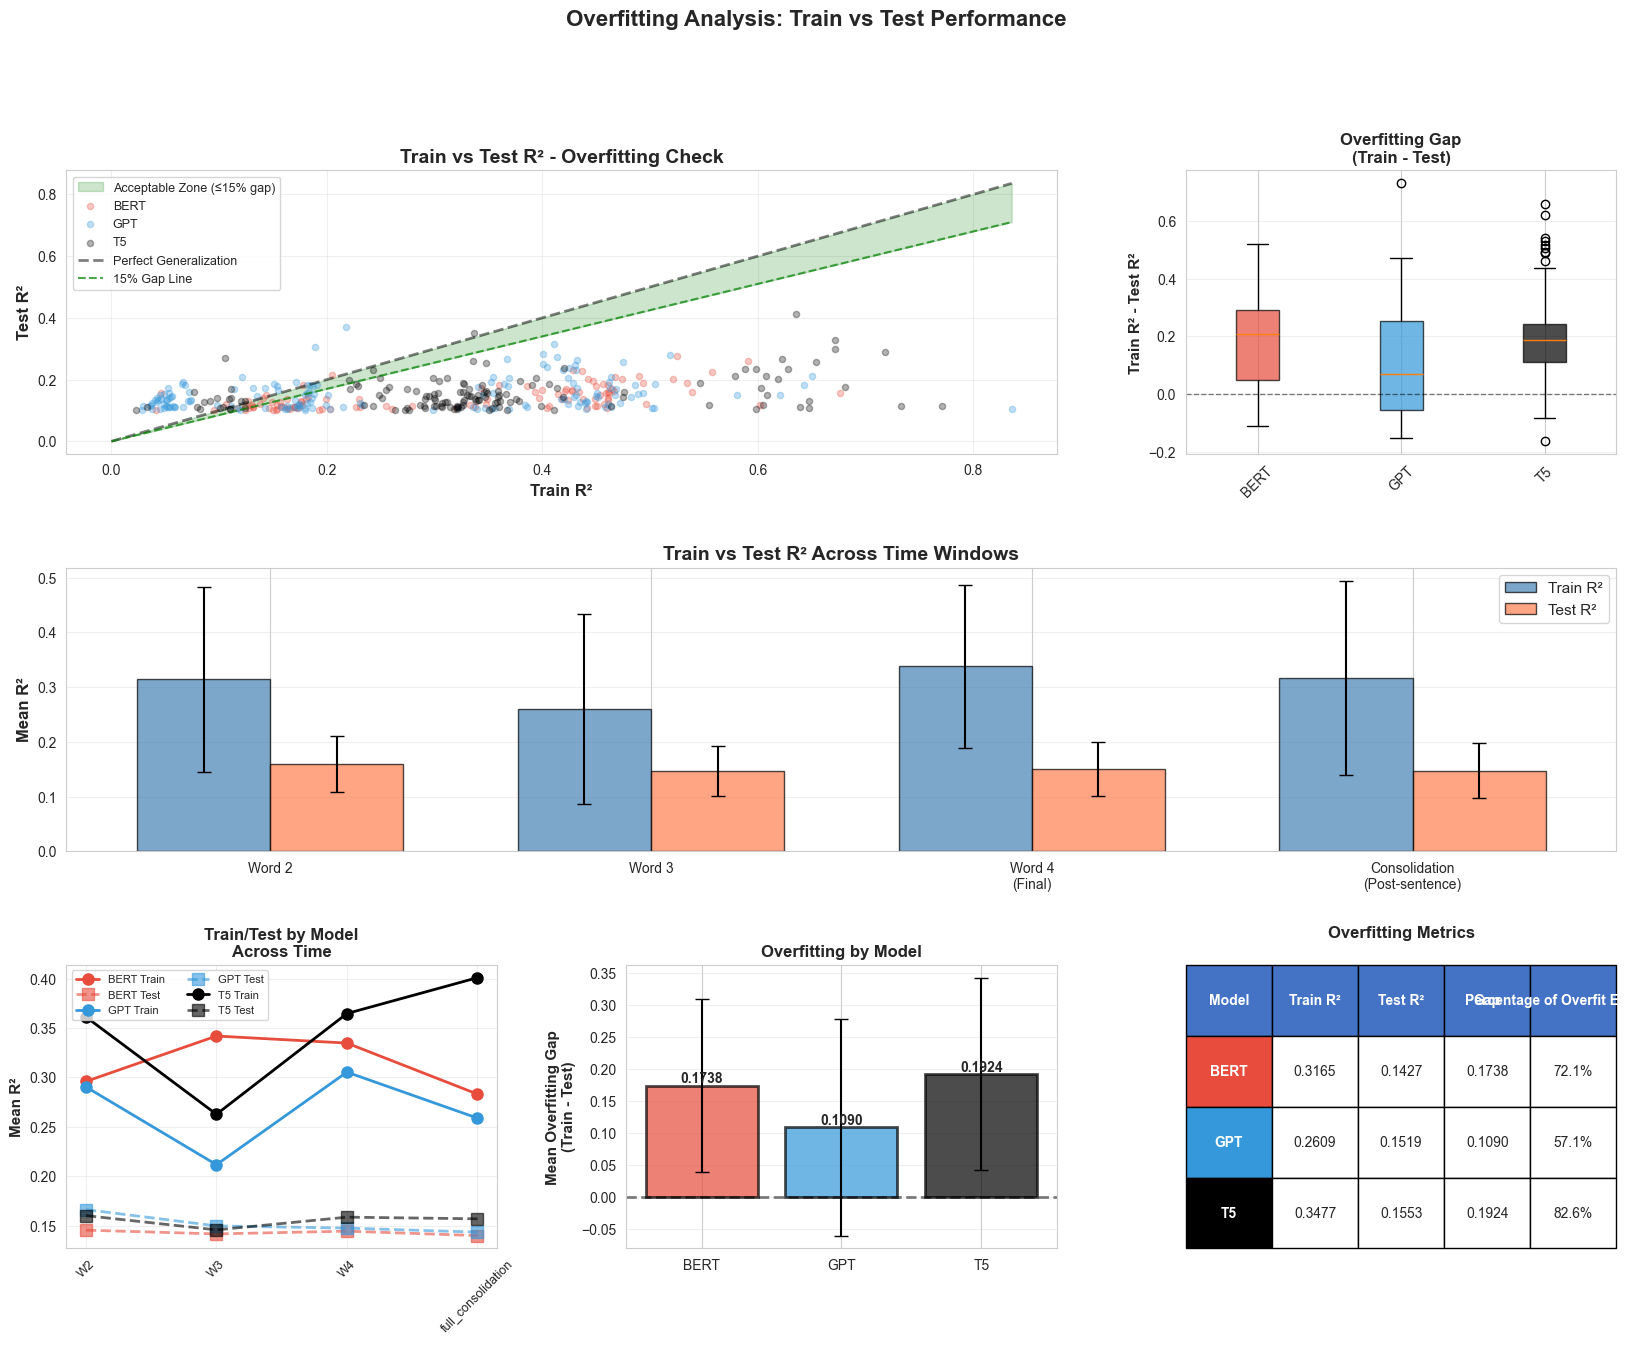

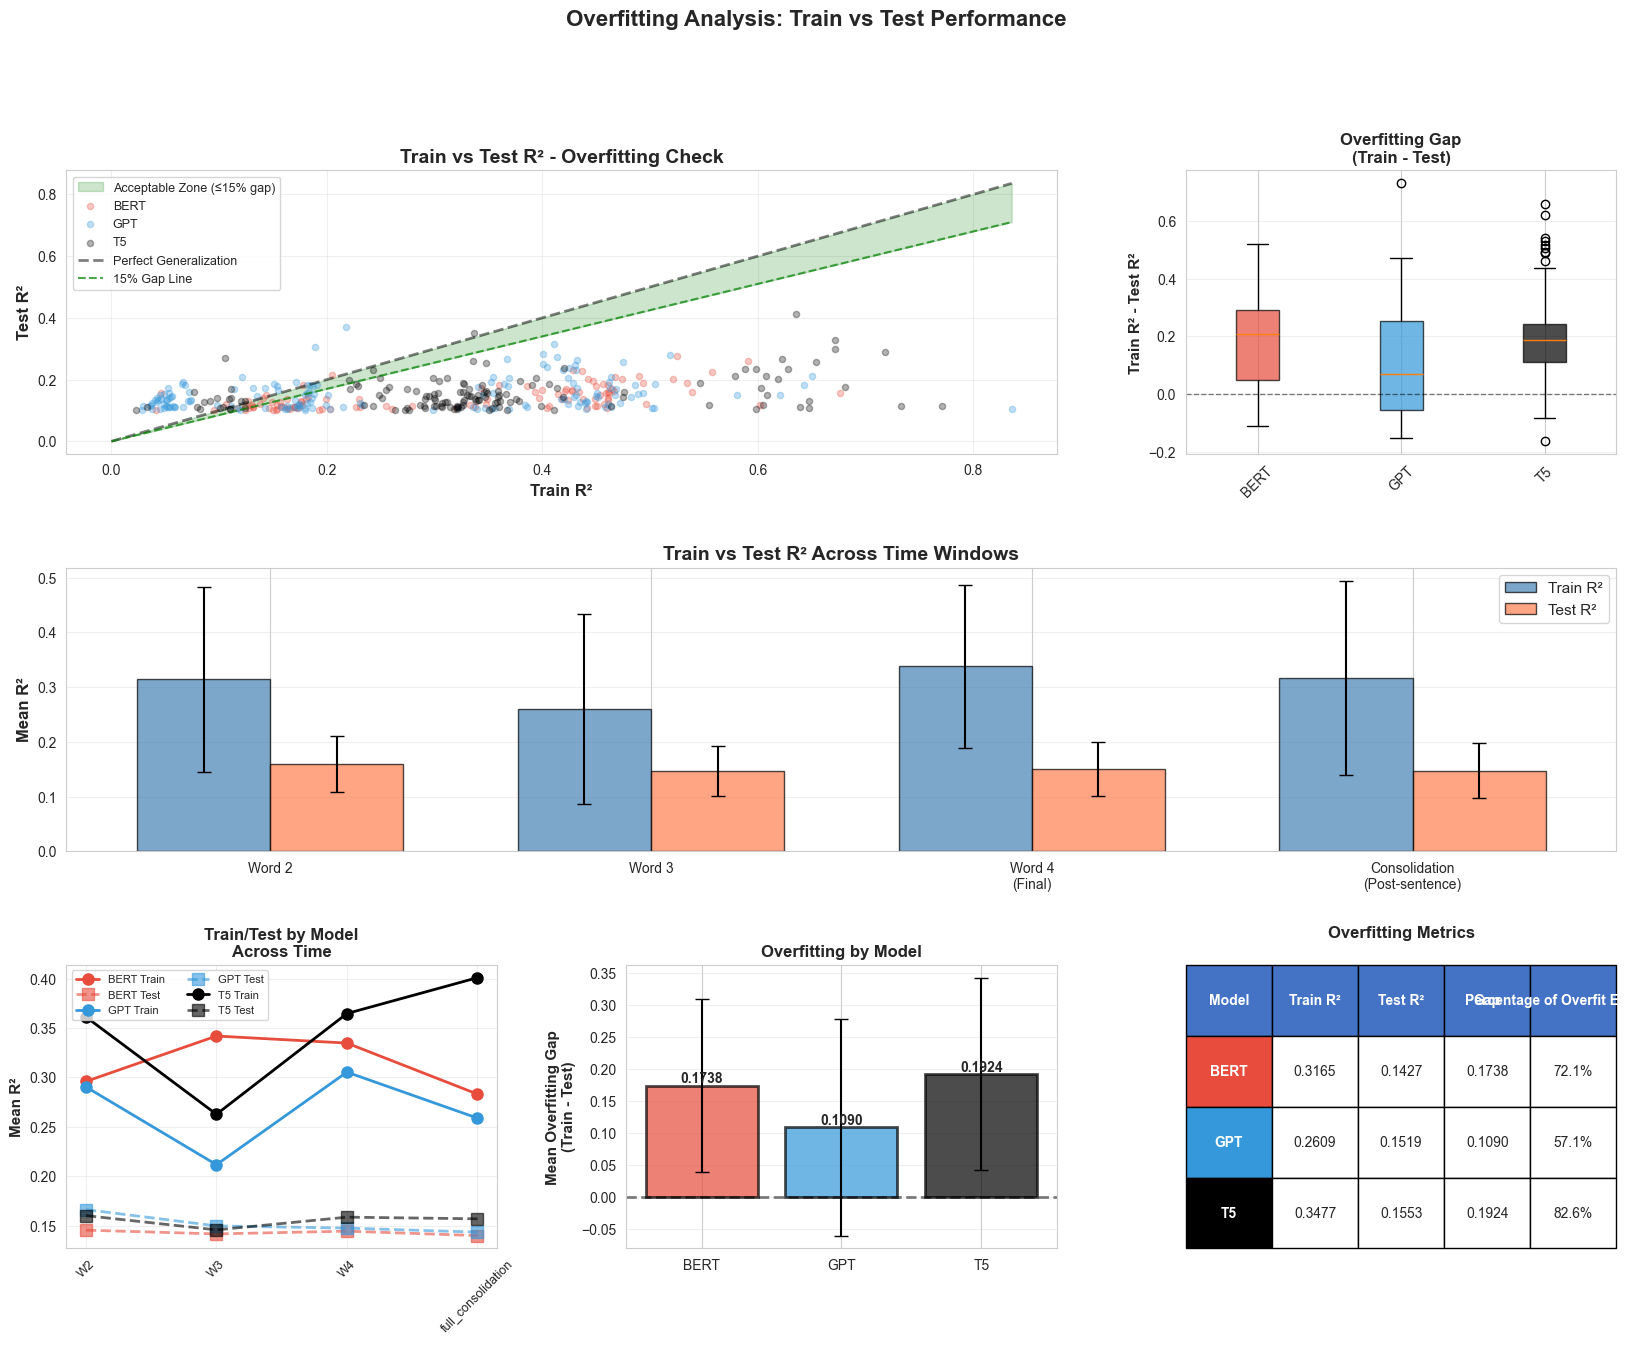

In [ ]:
def plot_overfitting_analysis(df, save_path=None):
    """
    Compare train vs test R² across models and time windows to detect overfitting
    Overfitting indicators:
    - Train R² >> Test R² (large gap)
    - Train R² high but test R² low
    """
    fig = plt.figure(figsize=(20, 14))
    gs = GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)
    
    # Filter for valid train R² values
    df_valid = df[(df['train_R_2'].notna()) & (df['train_R_2'] > -1)].copy()
    
    # Scatter plot: Train vs Test R² by model
    ax1 = fig.add_subplot(gs[0, :2])
    

    max_r2 = max(df_valid['train_R_2'].max(), df_valid['test_R_2'].max())
    train_vals = np.linspace(0, max_r2, 100)
    

    upper_bound = train_vals

    lower_bound = train_vals * 0.85
    
    ax1.fill_between(train_vals, lower_bound, upper_bound, 
                     alpha=0.2, color='green', 
                     label='Acceptable Zone (≤15% gap)')
    
    for model, color in MODEL_COLORS.items():
        model_data = df_valid[df_valid['model'] == model]
        ax1.scatter(model_data['train_R_2'], model_data['test_R_2'], 
                   alpha=0.3, s=20, c=color, label=model)
    
    # Add diagonal line (perfect generalization)
    ax1.plot([0, max_r2], [0, max_r2], 'k--', linewidth=2, alpha=0.5, label='Perfect Generalization')
    
    # Add 15% gap line
    ax1.plot(train_vals, lower_bound, 'g--', linewidth=1.5, alpha=0.7, label='15% Gap Line')
    
    ax1.set_xlabel('Train R²', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Test R²', fontsize=12, fontweight='bold')
    ax1.set_title('Train vs Test R² - Overfitting Check', fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # 2. Overfitting gap distribution by model
    ax2 = fig.add_subplot(gs[0, 2])
    df_valid['overfitting_gap'] = df_valid['train_R_2'] - df_valid['test_R_2']
    
    model_gaps = [df_valid[df_valid['model'] == model]['overfitting_gap'].values 
                  for model in MODELS]
    bp = ax2.boxplot(model_gaps, labels=MODELS, patch_artist=True)
    
    for patch, model in zip(bp['boxes'], MODELS):
        patch.set_facecolor(MODEL_COLORS[model])
        patch.set_alpha(0.7)
    
    ax2.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    ax2.set_ylabel('Train R² - Test R²', fontsize=11, fontweight='bold')
    ax2.set_title('Overfitting Gap\n(Train - Test)', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
    
    # 3. Train vs Test by time window
    ax3 = fig.add_subplot(gs[1, :])
    
    time_stats = df_valid.groupby('time_window').agg({
        'train_R_2': ['mean', 'std'],
        'test_R_2': ['mean', 'std']
    }).reindex(TIME_WINDOWS)
    
    x = np.arange(len(TIME_WINDOWS))
    width = 0.35
    
    ax3.bar(x - width/2, time_stats[('train_R_2', 'mean')], width,
           yerr=time_stats[('train_R_2', 'std')], label='Train R²',
           color='steelblue', alpha=0.7, capsize=5, edgecolor='black')
    ax3.bar(x + width/2, time_stats[('test_R_2', 'mean')], width,
           yerr=time_stats[('test_R_2', 'std')], label='Test R²',
           color='coral', alpha=0.7, capsize=5, edgecolor='black')
    
    ax3.set_xticks(x)
    ax3.set_xticklabels([TIME_WINDOW_LABELS[tw] for tw in TIME_WINDOWS], fontsize=10)
    ax3.set_ylabel('Mean R²', fontsize=12, fontweight='bold')
    ax3.set_title('Train vs Test R² Across Time Windows', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=11)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Train vs Test by model across time windows
    ax4 = fig.add_subplot(gs[2, 0])
    for model in MODELS:
        model_data = df_valid[df_valid['model'] == model]
        time_train = model_data.groupby('time_window')['train_R_2'].mean().reindex(TIME_WINDOWS)
        time_test = model_data.groupby('time_window')['test_R_2'].mean().reindex(TIME_WINDOWS)
        
        x = np.arange(len(TIME_WINDOWS))
        ax4.plot(x, time_train, 'o-', label=f'{model} Train', 
                color=MODEL_COLORS[model], linewidth=2, markersize=8)
        ax4.plot(x, time_test, 's--', label=f'{model} Test', 
                color=MODEL_COLORS[model], linewidth=2, markersize=8, alpha=0.6)
    
    ax4.set_xticks(x)
    ax4.set_xticklabels([tw for tw in TIME_WINDOWS], fontsize=9, rotation=45)
    ax4.set_ylabel('Mean R²', fontsize=11, fontweight='bold')
    ax4.set_title('Train/Test by Model\nAcross Time', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=8, ncol=2)
    ax4.grid(True, alpha=0.3)
    
    # 5. Model comparison: Average overfitting gap
    ax5 = fig.add_subplot(gs[2, 1])
    model_stats = df_valid.groupby('model').agg({
        'overfitting_gap': ['mean', 'std', 'count']
    })
    
    colors = [MODEL_COLORS[m] for m in MODELS]
    bars = ax5.bar(MODELS, model_stats[('overfitting_gap', 'mean')],
                   yerr=model_stats[('overfitting_gap', 'std')],
                   color=colors, alpha=0.7, capsize=5, edgecolor='black', linewidth=2)
    
    ax5.axhline(y=0, color='k', linestyle='--', linewidth=2, alpha=0.5)
    ax5.set_ylabel('Mean Overfitting Gap\n(Train - Test)', fontsize=11, fontweight='bold')
    ax5.set_title('Overfitting by Model', fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom' if height > 0 else 'top',
                fontweight='bold', fontsize=10)
    
    # 6. Overfitting metrics table
    ax6 = fig.add_subplot(gs[2, 2])
    ax6.axis('tight')
    ax6.axis('off')
    
    # Calculate overfitting metrics
    metrics_data = []
    for model in MODELS:
        model_data = df_valid[df_valid['model'] == model]
        mean_train = model_data['train_R_2'].mean()
        mean_test = model_data['test_R_2'].mean()
        mean_gap = model_data['overfitting_gap'].mean()
        
        # Percentage of high-overfitting cases (gap > 0.05)
        high_overfit_pct = (model_data['overfitting_gap'] > 0.05).mean() * 100
        
        metrics_data.append([
            model,
            f'{mean_train:.4f}',
            f'{mean_test:.4f}',
            f'{mean_gap:.4f}',
            f'{high_overfit_pct:.1f}%'
        ])
    
    table = ax6.table(cellText=metrics_data,
                     colLabels=['Model', 'Train R²', 'Test R²', 'Gap', 'Percentage of Overfit Electrodes'], #Make this label shorter
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0, 1, 1])
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Color code the header
    for i in range(5):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Color code model rows
    for i, model in enumerate(MODELS):
        table[(i+1, 0)].set_facecolor(MODEL_COLORS[model])
        table[(i+1, 0)].set_text_props(weight='bold', color='white')
    
    ax6.set_title('Overfitting Metrics', fontsize=12, fontweight='bold', pad=20)
    
    plt.suptitle('Overfitting Analysis: Train vs Test Performance', 
                fontsize=16, fontweight='bold', y=0.995)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.tight_layout()
    return fig

plot_overfitting_analysis(sig_df)

Saved: alpha_analysis.png


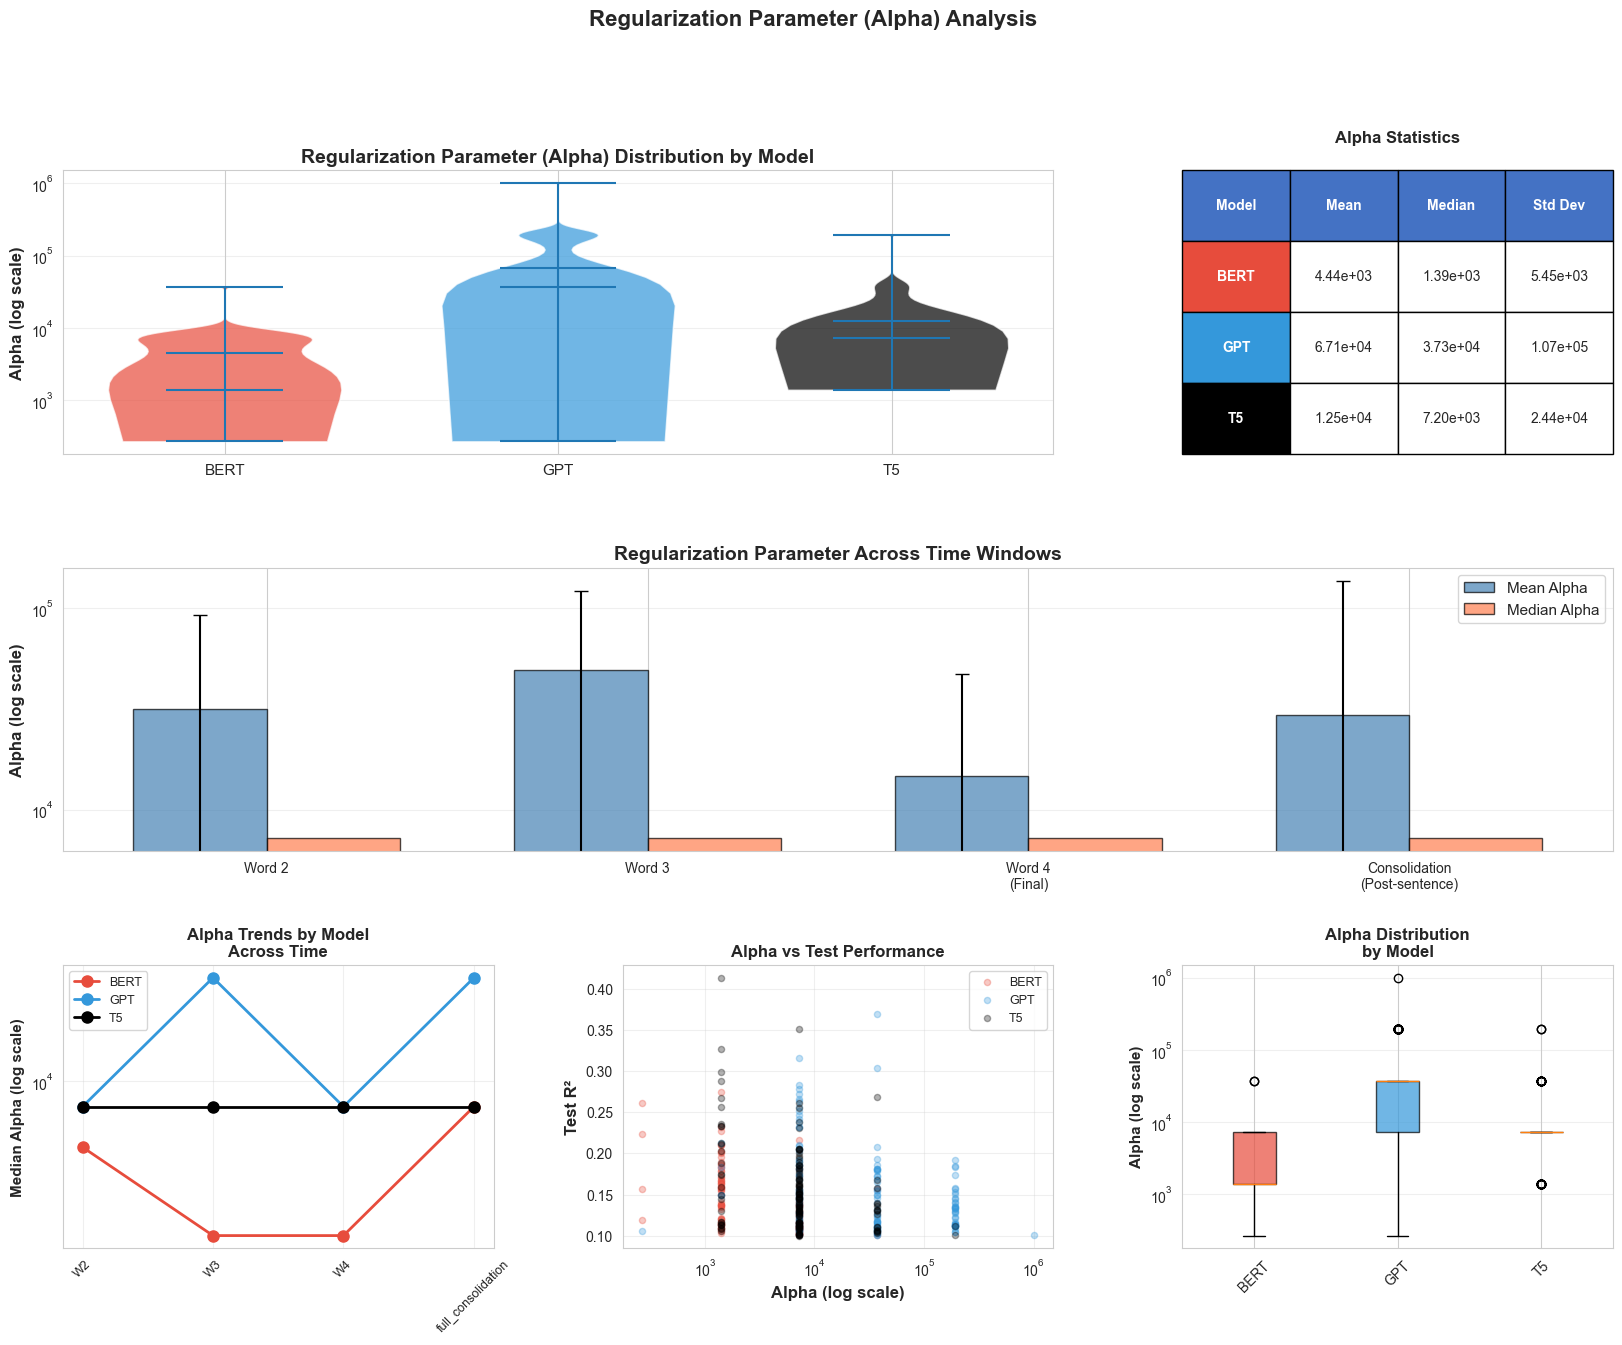

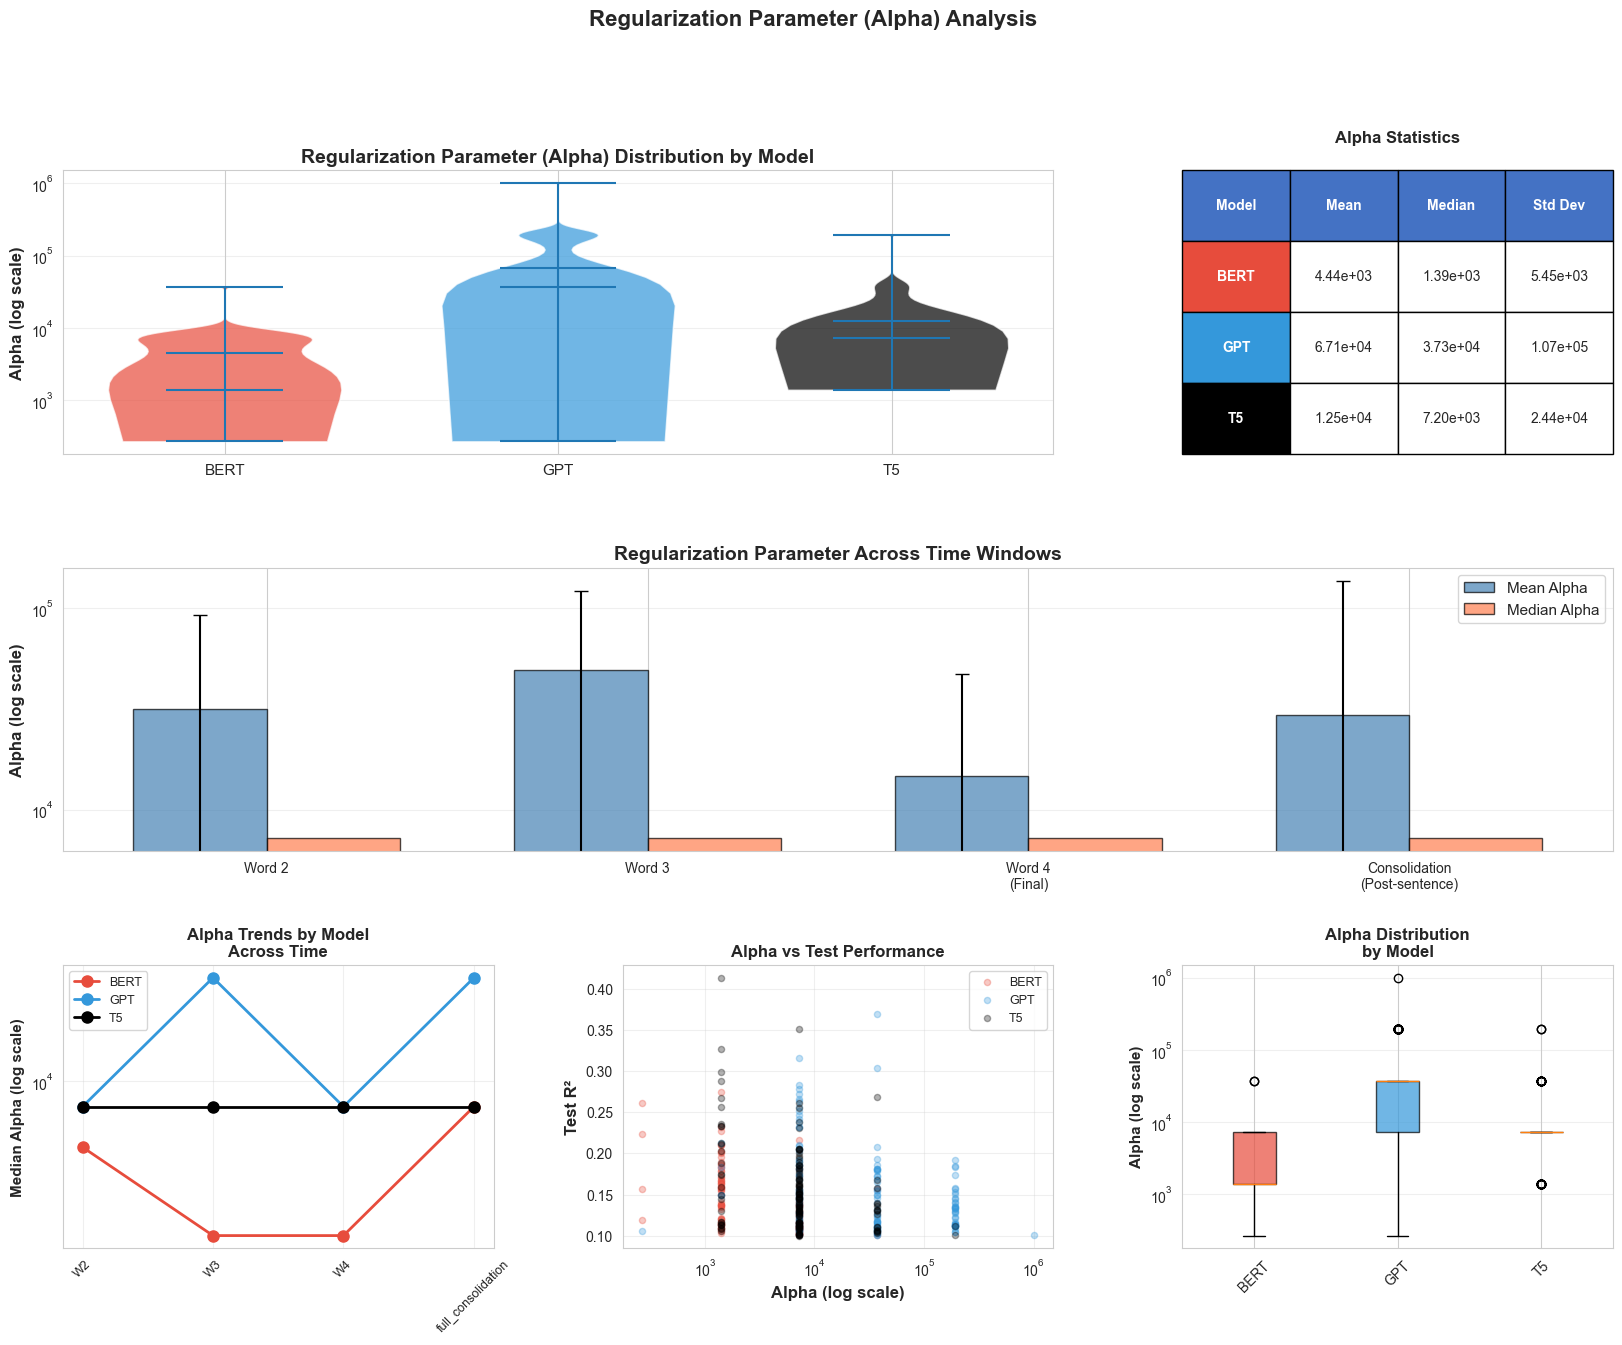

In [ ]:
def plot_alpha_analysis(df, save_path=None):
    """
    Visualize regularization parameter (alpha) distribution across models and time windows
    Shows:
    - Alpha distribution by model
    - Alpha trends across time windows
    - Relationship between alpha and model performance
    """
    fig = plt.figure(figsize=(20, 14))
    gs = GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)
    
    # Filter for valid alpha values
    df_valid = df[(df['best_alpha'].notna()) & (df['best_alpha'] > 0)].copy()
    
    #Alpha distribution by model violins
    ax1 = fig.add_subplot(gs[0, :2])
    
    model_alphas = [df_valid[df_valid['model'] == model]['best_alpha'].values 
                    for model in MODELS]
    
    parts = ax1.violinplot(model_alphas, positions=range(len(MODELS)), 
                          showmeans=True, showmedians=True, widths=0.7)
    
    # Color the violin plots
    for i, (pc, model) in enumerate(zip(parts['bodies'], MODELS)):
        pc.set_facecolor(MODEL_COLORS[model])
        pc.set_alpha(0.7)
    
    ax1.set_xticks(range(len(MODELS)))
    ax1.set_xticklabels(MODELS, fontsize=11)
    ax1.set_ylabel('Alpha (log scale)', fontsize=12, fontweight='bold')
    ax1.set_yscale('log')
    ax1.set_title('Regularization Parameter (Alpha) Distribution by Model', 
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # 2. Alpha statistics table
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.axis('tight')
    ax2.axis('off')
    
    stats_data = []
    for model in MODELS:
        model_data = df_valid[df_valid['model'] == model]['best_alpha']
        stats_data.append([
            model,
            f'{model_data.mean():.2e}',
            f'{model_data.median():.2e}',
            f'{model_data.std():.2e}'
        ])
    
    table = ax2.table(cellText=stats_data,
                     colLabels=['Model', 'Mean', 'Median', 'Std Dev'],
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0, 1, 1])
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Color code the header
    for i in range(4):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Color code model rows
    for i, model in enumerate(MODELS):
        table[(i+1, 0)].set_facecolor(MODEL_COLORS[model])
        table[(i+1, 0)].set_text_props(weight='bold', color='white')
    
    ax2.set_title('Alpha Statistics', fontsize=12, fontweight='bold', pad=20)
    
    # 3. Alpha across time windows
    ax3 = fig.add_subplot(gs[1, :])
    
    time_stats = df_valid.groupby('time_window').agg({
        'best_alpha': ['mean', 'median', 'std']
    }).reindex(TIME_WINDOWS)
    
    x = np.arange(len(TIME_WINDOWS))
    width = 0.35
    
    ax3.bar(x - width/2, time_stats[('best_alpha', 'mean')], width,
           yerr=time_stats[('best_alpha', 'std')], label='Mean Alpha',
           color='steelblue', alpha=0.7, capsize=5, edgecolor='black')
    ax3.bar(x + width/2, time_stats[('best_alpha', 'median')], width,
           label='Median Alpha',
           color='coral', alpha=0.7, capsize=5, edgecolor='black')
    
    ax3.set_xticks(x)
    ax3.set_xticklabels([TIME_WINDOW_LABELS[tw] for tw in TIME_WINDOWS], fontsize=10)
    ax3.set_ylabel('Alpha (log scale)', fontsize=12, fontweight='bold')
    ax3.set_yscale('log')
    ax3.set_title('Regularization Parameter Across Time Windows', 
                  fontsize=14, fontweight='bold')
    ax3.legend(fontsize=11)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Alpha trends by model across time windows
    ax4 = fig.add_subplot(gs[2, 0])
    
    for model in MODELS:
        model_data = df_valid[df_valid['model'] == model]
        time_alpha = model_data.groupby('time_window')['best_alpha'].median().reindex(TIME_WINDOWS)
        
        x = np.arange(len(TIME_WINDOWS))
        ax4.plot(x, time_alpha, 'o-', label=model, 
                color=MODEL_COLORS[model], linewidth=2, markersize=8)
    
    ax4.set_xticks(x)
    ax4.set_xticklabels([tw for tw in TIME_WINDOWS], fontsize=9, rotation=45)
    ax4.set_ylabel('Median Alpha (log scale)', fontsize=11, fontweight='bold')
    ax4.set_yscale('log')
    ax4.set_title('Alpha Trends by Model\nAcross Time', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3)
    
    # 5. Alpha vs Test R squared relationship
    ax5 = fig.add_subplot(gs[2, 1])
    
    for model, color in MODEL_COLORS.items():
        model_data = df_valid[df_valid['model'] == model]
        ax5.scatter(model_data['best_alpha'], model_data['test_R_2'], 
                   alpha=0.3, s=20, c=color, label=model)
    
    ax5.set_xlabel('Alpha (log scale)', fontsize=12, fontweight='bold')
    ax5.set_ylabel('Test R²', fontsize=12, fontweight='bold')
    ax5.set_xscale('log')
    ax5.set_title('Alpha vs Test Performance', fontsize=12, fontweight='bold')
    ax5.legend(loc='best', fontsize=9)
    ax5.grid(True, alpha=0.3)
    
    # 6. Box plot of alpha by model
    ax6 = fig.add_subplot(gs[2, 2])
    
    model_alphas = [df_valid[df_valid['model'] == model]['best_alpha'].values 
                    for model in MODELS]
    bp = ax6.boxplot(model_alphas, labels=MODELS, patch_artist=True)
    
    for patch, model in zip(bp['boxes'], MODELS):
        patch.set_facecolor(MODEL_COLORS[model])
        patch.set_alpha(0.7)
    
    ax6.set_ylabel('Alpha (log scale)', fontsize=11, fontweight='bold')
    ax6.set_yscale('log')
    ax6.set_title('Alpha Distribution\nby Model', fontsize=12, fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='y')
    plt.setp(ax6.xaxis.get_majorticklabels(), rotation=45)
    
    plt.suptitle('Regularization Parameter (Alpha) Analysis', 
                fontsize=16, fontweight='bold', y=0.995)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.tight_layout()
    return fig


plot_alpha_analysis(sig_df, save_path='alpha_analysis.png')

## 4. Temporal Dynamics Analysis

### 4.1 Overall Temporal Progression

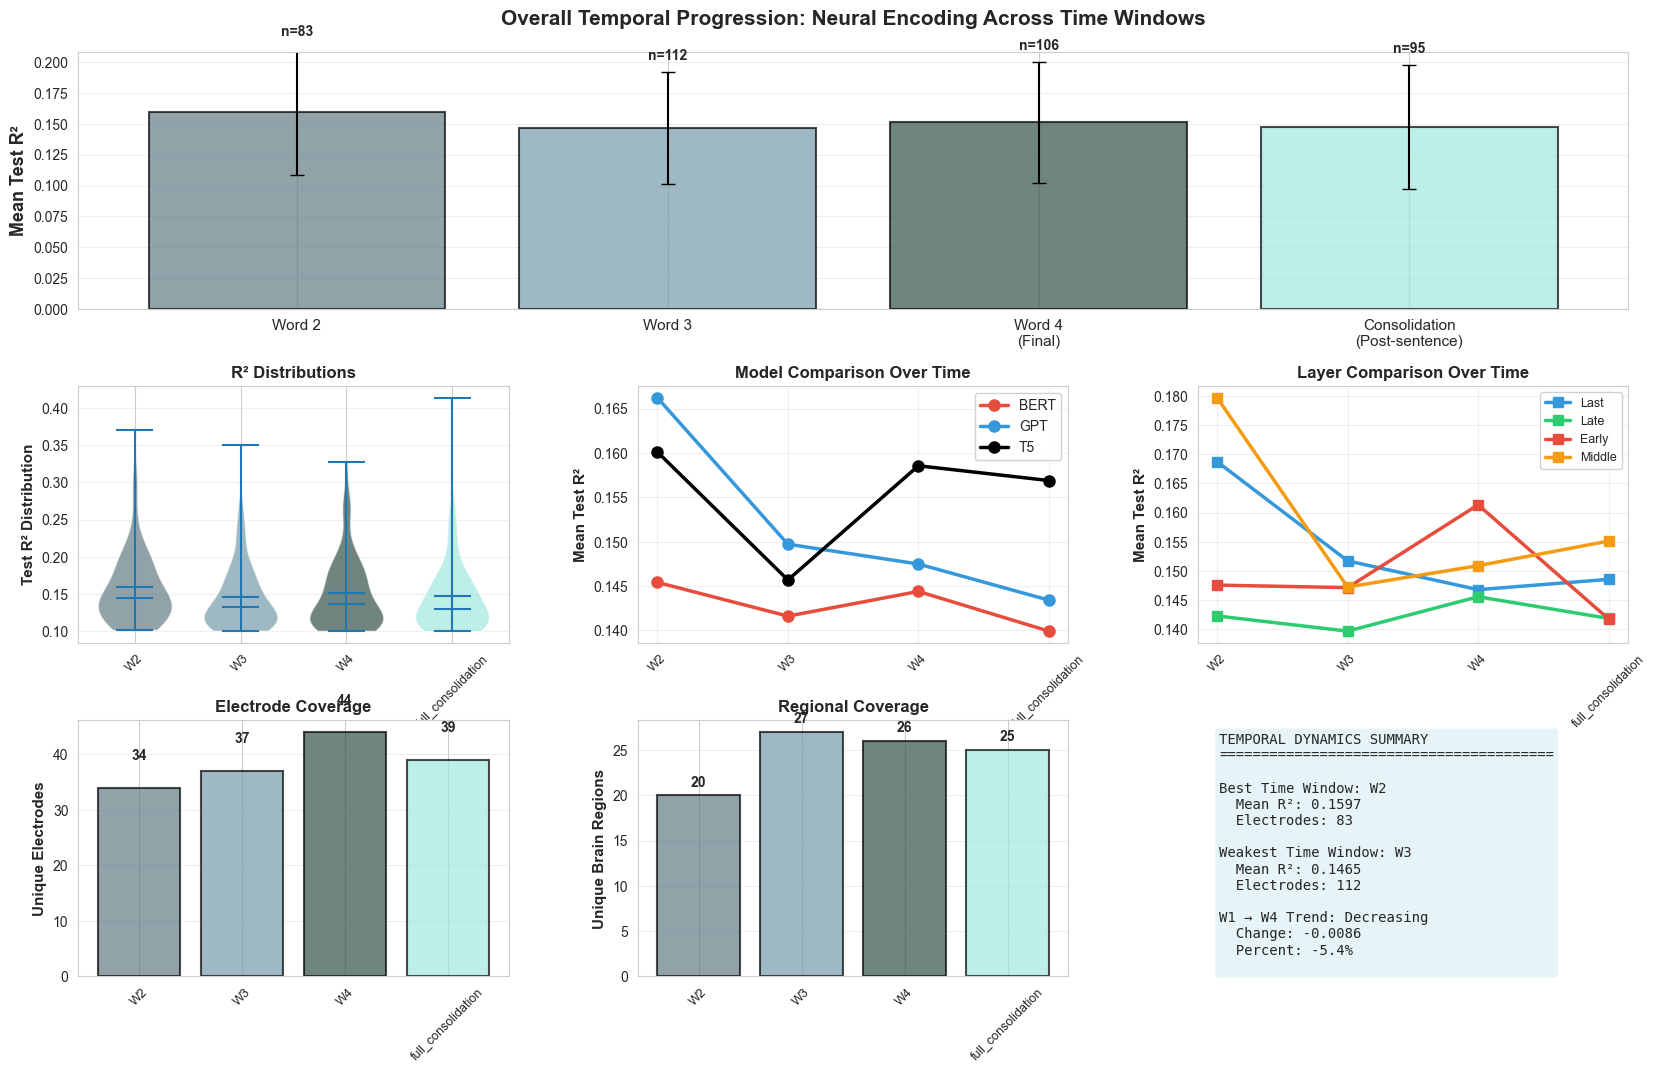

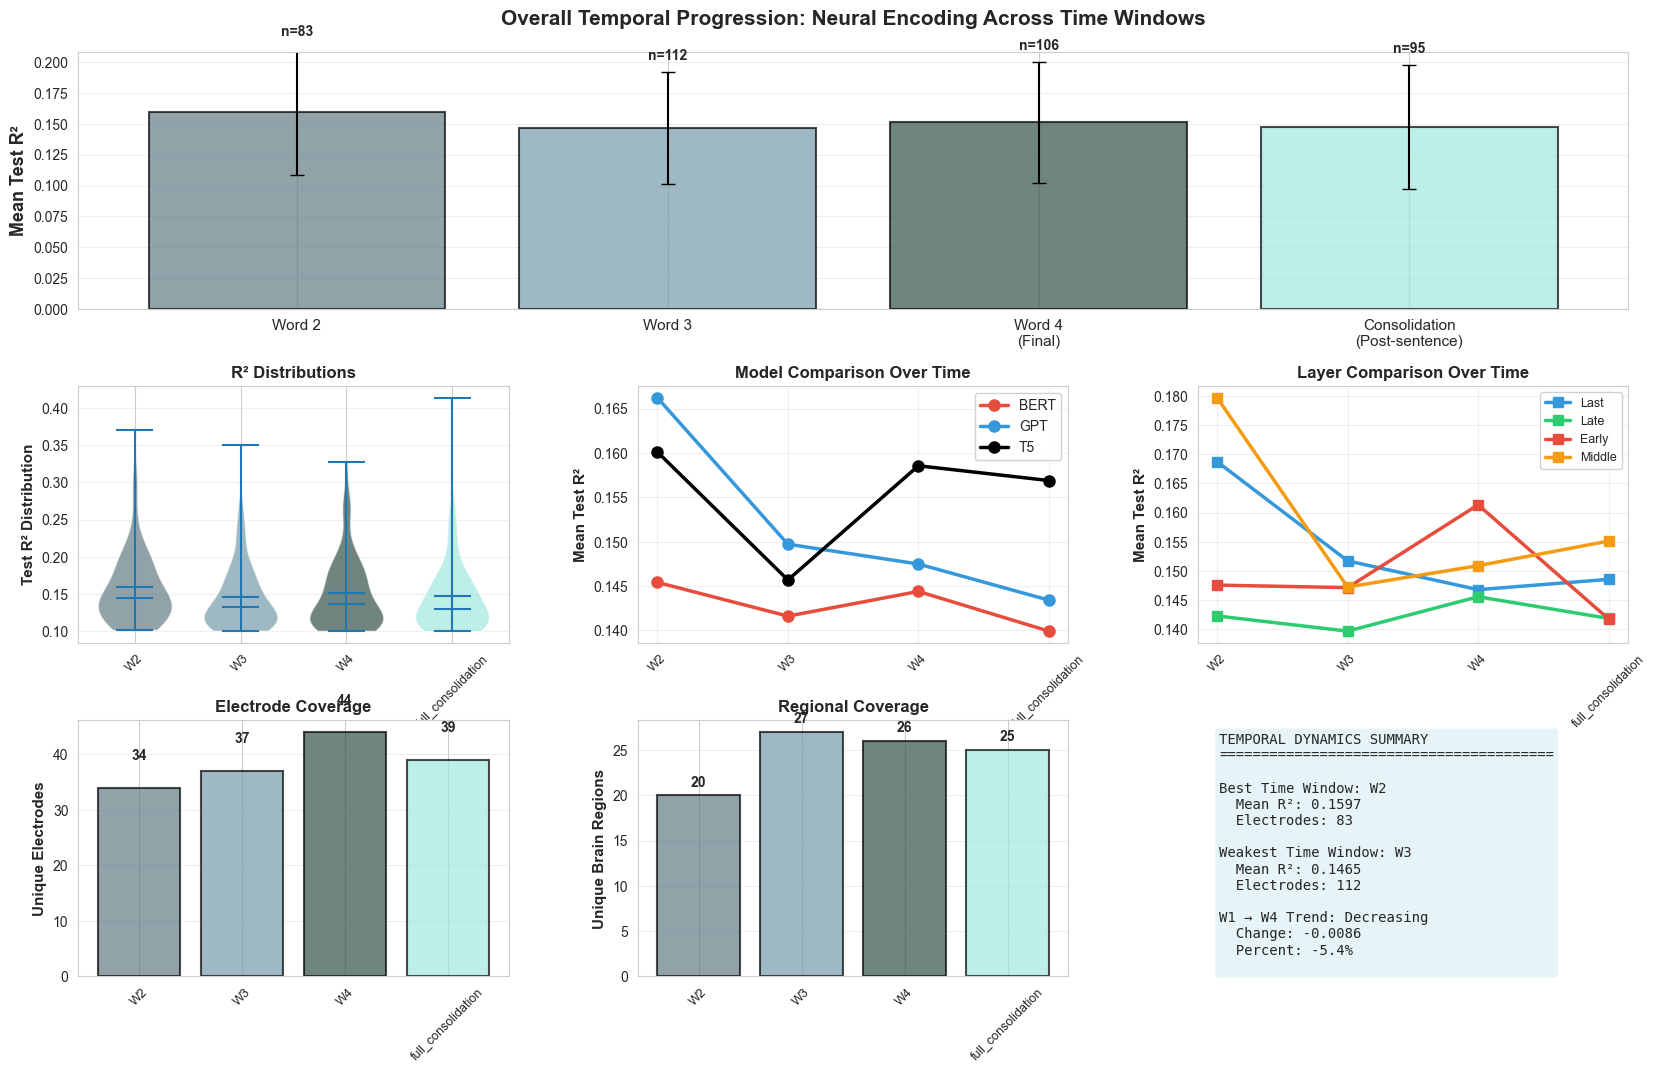

In [ ]:
def plot_temporal_progression_overview(df, save_path=None):
    """
    Create comprehensive overview of temporal dynamics
    """
    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)
    
    # 1. Overall progression across time windows
    ax1 = fig.add_subplot(gs[0, :])
    time_stats = df.groupby('time_window')['test_R_2'].agg(['mean', 'std', 'count']).reindex(TIME_WINDOWS)
    
    x_pos = np.arange(len(TIME_WINDOWS))
    ax1.bar(x_pos, time_stats['mean'], yerr=time_stats['std'], 
            color=[TIME_WINDOW_COLORS[tw] for tw in TIME_WINDOWS],
            alpha=0.7, capsize=5, edgecolor='black', linewidth=1.5)
    
    # Add count labels
    for i, (tw, row) in enumerate(time_stats.iterrows()):
        ax1.text(i, row['mean'] + row['std'] + 0.01, 
                f"n={int(row['count'])}",
                ha='center', fontsize=10, fontweight='bold')
    
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([TIME_WINDOW_LABELS[tw] for tw in TIME_WINDOWS], fontsize=11)
    ax1.set_ylabel('Mean Test R²', fontsize=13, fontweight='bold')
    ax1.set_title('Overall Temporal Progression: Neural Encoding Across Time Windows', 
                  fontsize=15, fontweight='bold', pad=20)
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_ylim(0, time_stats['mean'].max() * 1.3)
    
    # 2. Distribution by time window  violins
    ax2 = fig.add_subplot(gs[1, 0])
    parts = ax2.violinplot(
        [df[df['time_window'] == tw]['test_R_2'].values for tw in TIME_WINDOWS],
        positions=x_pos, widths=0.7, showmeans=True, showmedians=True
    )
    
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(TIME_WINDOW_COLORS[TIME_WINDOWS[i]])
        pc.set_alpha(0.7)
    
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([tw for tw in TIME_WINDOWS], fontsize=9, rotation=45)
    ax2.set_ylabel('Test R² Distribution', fontsize=11, fontweight='bold')
    ax2.set_title('R² Distributions', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Model comparison across time
    ax3 = fig.add_subplot(gs[1, 1])
    for model in MODELS:
        model_data = df[df['model'] == model].groupby('time_window')['test_R_2'].mean().reindex(TIME_WINDOWS)
        ax3.plot(x_pos, model_data.values, marker='o', linewidth=2.5, 
                label=model, color=MODEL_COLORS[model], markersize=8)
    
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels([tw for tw in TIME_WINDOWS], fontsize=9, rotation=45)
    ax3.set_ylabel('Mean Test R²', fontsize=11, fontweight='bold')
    ax3.set_title('Model Comparison Over Time', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=10, framealpha=0.9)
    ax3.grid(True, alpha=0.3)
    
    # 4. Layer comparison across time
    ax4 = fig.add_subplot(gs[1, 2])
    layer_colors = {'early': '#e74c3c', 'middle': '#f39c12', 'late': '#2ecc71', 'last': '#3498db'}
    for layer in LAYERS:
        layer_data = df[df['layer'] == layer].groupby('time_window')['test_R_2'].mean().reindex(TIME_WINDOWS)
        ax4.plot(x_pos, layer_data.values, marker='s', linewidth=2.5, 
                label=layer.capitalize(), color=layer_colors[layer], markersize=7)
    
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels([tw for tw in TIME_WINDOWS], fontsize=9, rotation=45)
    ax4.set_ylabel('Mean Test R²', fontsize=11, fontweight='bold')
    ax4.set_title('Layer Comparison Over Time', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=9, framealpha=0.9)
    ax4.grid(True, alpha=0.3)
    
    # 5. Electrode count per time window
    ax5 = fig.add_subplot(gs[2, 0])
    electrode_counts = df.groupby('time_window')['electrode'].nunique().reindex(TIME_WINDOWS)
    ax5.bar(x_pos, electrode_counts.values, 
            color=[TIME_WINDOW_COLORS[tw] for tw in TIME_WINDOWS],
            alpha=0.7, edgecolor='black', linewidth=1.5)
    
    for i, count in enumerate(electrode_counts.values):
        ax5.text(i, count + 5, str(int(count)), ha='center', fontsize=10, fontweight='bold')
    
    ax5.set_xticks(x_pos)
    ax5.set_xticklabels([tw for tw in TIME_WINDOWS], fontsize=9, rotation=45)
    ax5.set_ylabel('Unique Electrodes', fontsize=11, fontweight='bold')
    ax5.set_title('Electrode Coverage', fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')
    
    # 6. Brain region count per time window
    ax6 = fig.add_subplot(gs[2, 1])
    region_counts = df.groupby('time_window')['parcLabel'].nunique().reindex(TIME_WINDOWS)
    ax6.bar(x_pos, region_counts.values, 
            color=[TIME_WINDOW_COLORS[tw] for tw in TIME_WINDOWS],
            alpha=0.7, edgecolor='black', linewidth=1.5)
    
    for i, count in enumerate(region_counts.values):
        ax6.text(i, count + 1, str(int(count)), ha='center', fontsize=10, fontweight='bold')
    
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels([tw for tw in TIME_WINDOWS], fontsize=9, rotation=45)
    ax6.set_ylabel('Unique Brain Regions', fontsize=11, fontweight='bold')
    ax6.set_title('Regional Coverage', fontsize=12, fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='y')
    
    # 7. Statistical summary
    ax7 = fig.add_subplot(gs[2, 2])
    ax7.axis('off')
    
    summary_text = "TEMPORAL DYNAMICS SUMMARY\n" + "="*40 + "\n\n"
    
    # Best time window
    best_tw = time_stats['mean'].idxmax()
    summary_text += f"Best Time Window: {best_tw}\n"
    summary_text += f"  Mean R²: {time_stats.loc[best_tw, 'mean']:.4f}\n"
    summary_text += f"  Electrodes: {int(time_stats.loc[best_tw, 'count'])}\n\n"
    
    # Worst time window
    worst_tw = time_stats['mean'].idxmin()
    summary_text += f"Weakest Time Window: {worst_tw}\n"
    summary_text += f"  Mean R²: {time_stats.loc[worst_tw, 'mean']:.4f}\n"
    summary_text += f"  Electrodes: {int(time_stats.loc[worst_tw, 'count'])}\n\n"
    
    # Temporal trend
    w2_r2 = time_stats.loc['W2', 'mean']
    w4_r2 = time_stats.loc['W4', 'mean']
    trend = "Increasing" if w4_r2 > w2_r2 else "Decreasing"
    summary_text += f"W1 → W4 Trend: {trend}\n"
    summary_text += f"  Change: {(w4_r2 - w2_r2):.4f}\n"
    summary_text += f"  Percent: {((w4_r2/w2_r2 - 1)*100):.1f}%\n"
    
    ax7.text(0.05, 0.95, summary_text, transform=ax7.transAxes,
            fontsize=10, verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return fig


# Generate overview
plot_temporal_progression_overview(
    sig_df, 
    save_path='figures/time_window_viz/temporal_dynamics/overview.png'
)

### 4.2 Individual Electrode Temporal Profiles

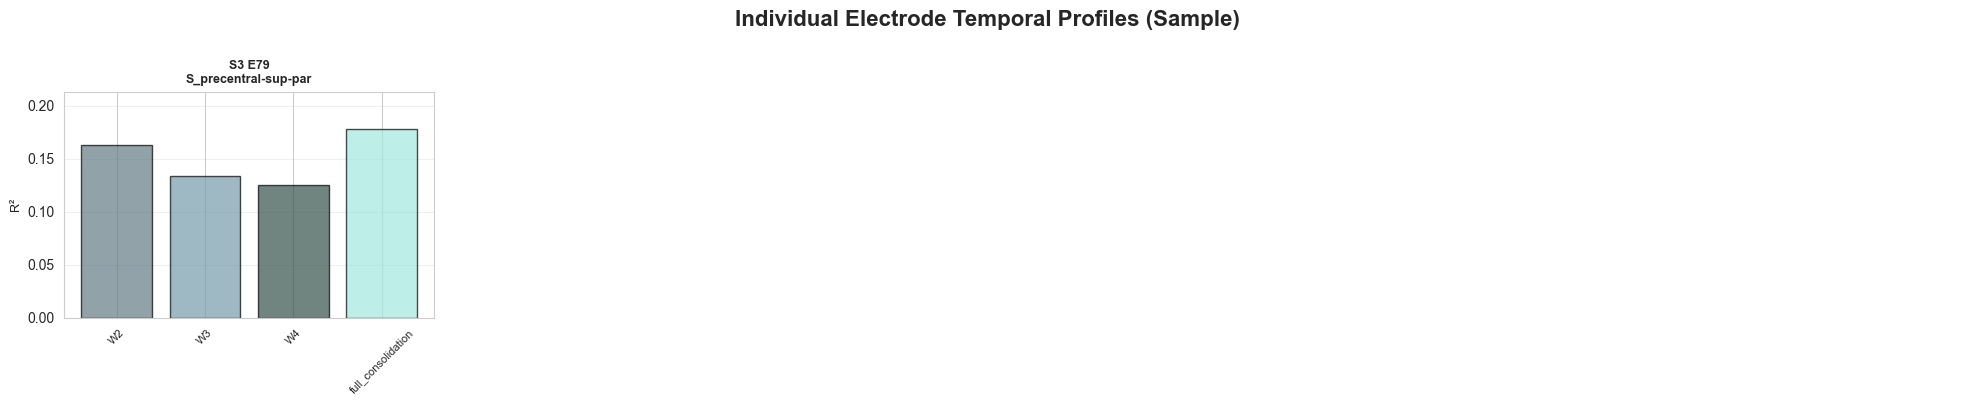

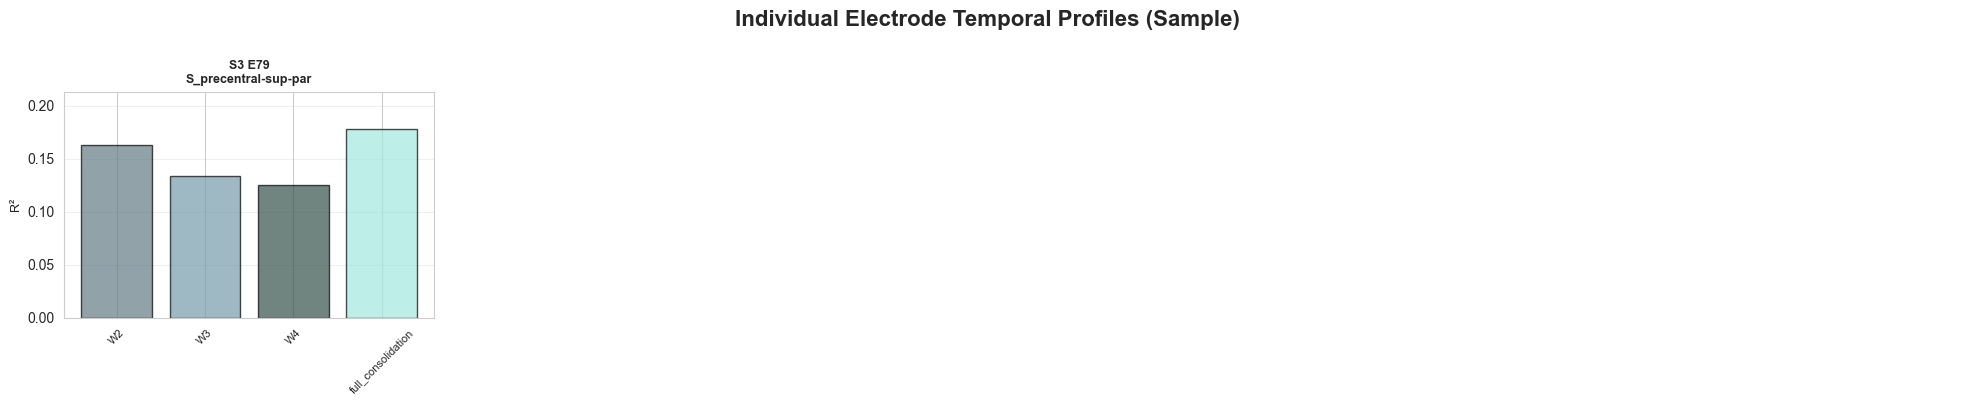

In [90]:
def plot_electrode_temporal_profiles(df, n_examples=20, save_path=None):
    """
    Show temporal profiles of individual electrodes (micro-level view)
    """
    # Get electrodes with data across all time windows
    electrode_coverage = df.groupby(['subject', 'electrode'])['time_window'].nunique()
    complete_electrodes = electrode_coverage[electrode_coverage == len(TIME_WINDOWS)].index
    
    # Sample electrodes
    np.random.seed(42)
    if len(complete_electrodes) > n_examples:
        sampled = np.random.choice(len(complete_electrodes), n_examples, replace=False)
        selected_electrodes = [complete_electrodes[i] for i in sampled]
    else:
        selected_electrodes = list(complete_electrodes)
    
    # Create figure
    n_cols = 5
    n_rows = int(np.ceil(len(selected_electrodes) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
    axes = axes.flatten()
    
    for idx, (subj, elec) in enumerate(selected_electrodes):
        if idx >= len(axes):
            break
            
        
        # Get electrode data
        elec_data = df[(df['subject'] == subj) & (df['electrode'] == elec)]
        temporal_profile = elec_data.groupby('time_window')['test_R_2'].mean().reindex(TIME_WINDOWS)
        
        # Plot
        x_pos = np.arange(len(TIME_WINDOWS))
        bars = axes[idx].bar(x_pos, temporal_profile.values, 
                     color=[TIME_WINDOW_COLORS[tw] for tw in TIME_WINDOWS],
                     alpha=0.7, edgecolor='black')
        
        # Get region info
        region = elec_data['parcLabel'].iloc[0]
        
        axes[idx].set_xticks(x_pos)
        axes[idx].set_xticklabels([tw for tw in TIME_WINDOWS], fontsize=8, rotation=45)
        axes[idx].set_ylabel('R²', fontsize=9)
        axes[idx].set_title(f'S{subj} E{elec}\n{region[:20]}', fontsize=9, fontweight='bold')
        axes[idx].grid(True, alpha=0.3, axis='y')
        axes[idx].set_ylim(0, temporal_profile.max() * 1.2)
    
    # Hide unused subplots
    for idx in range(len(selected_electrodes), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Individual Electrode Temporal Profiles (Sample)', 
                fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return fig


# Generate electrode profiles
plot_electrode_temporal_profiles(
    sig_df, 
    n_examples=20,
    save_path='figures/time_window_viz/temporal_dynamics/electrode_profiles.png'
)

### 4.3 Regional Temporal Dynamics

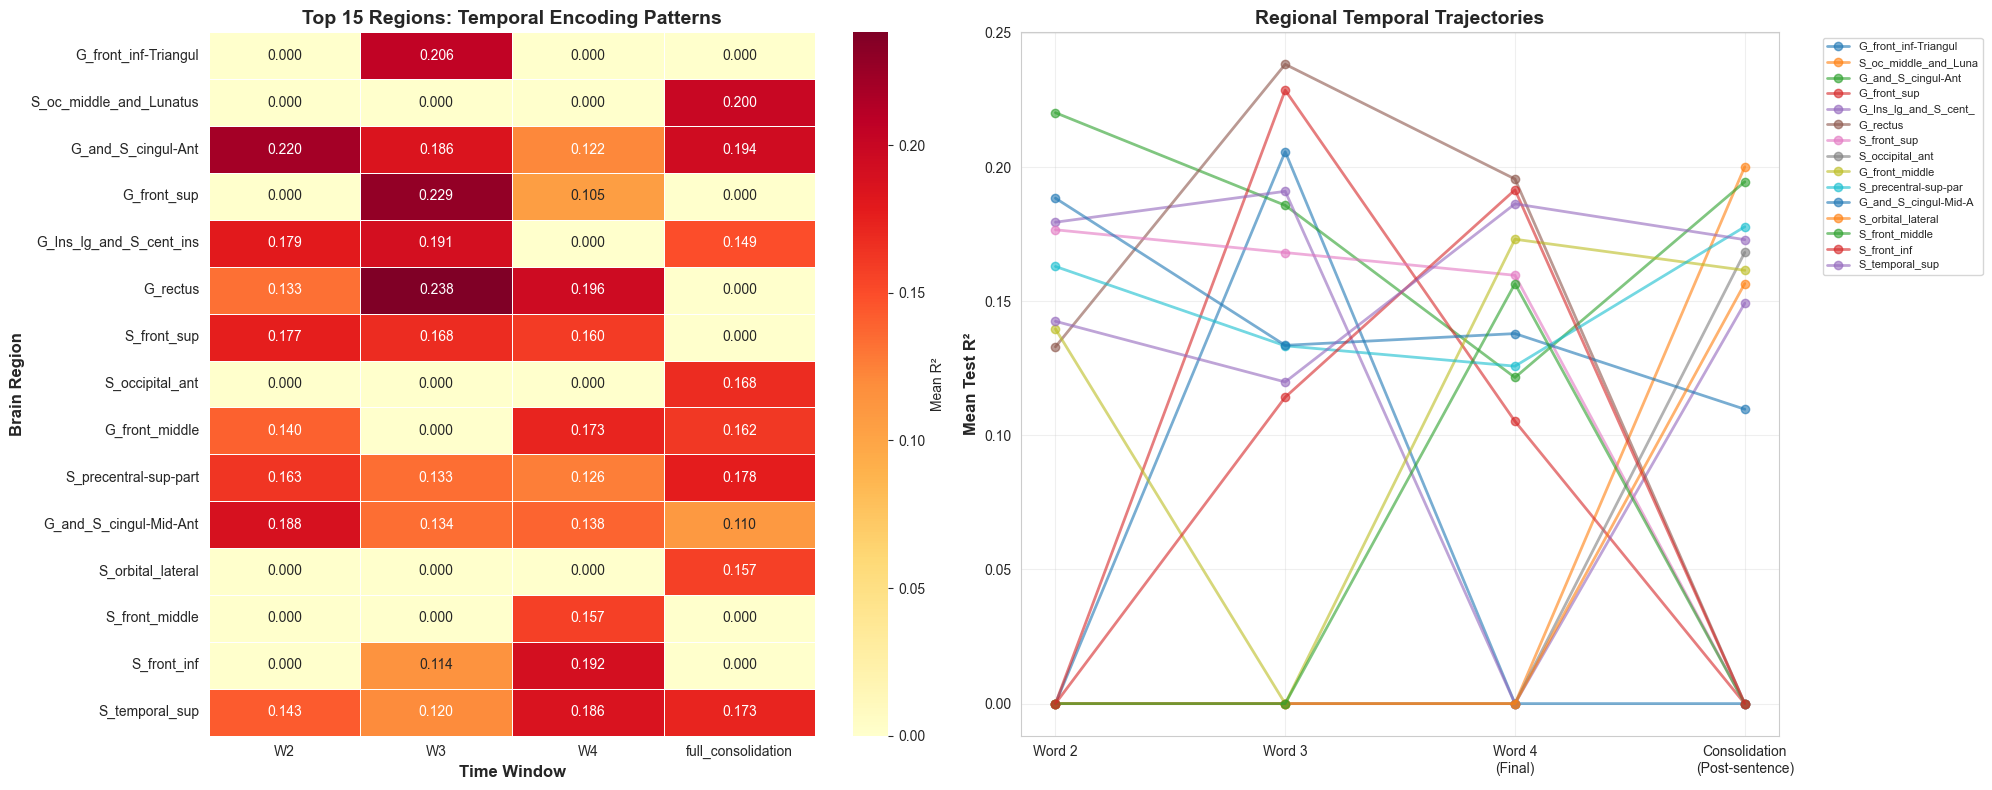

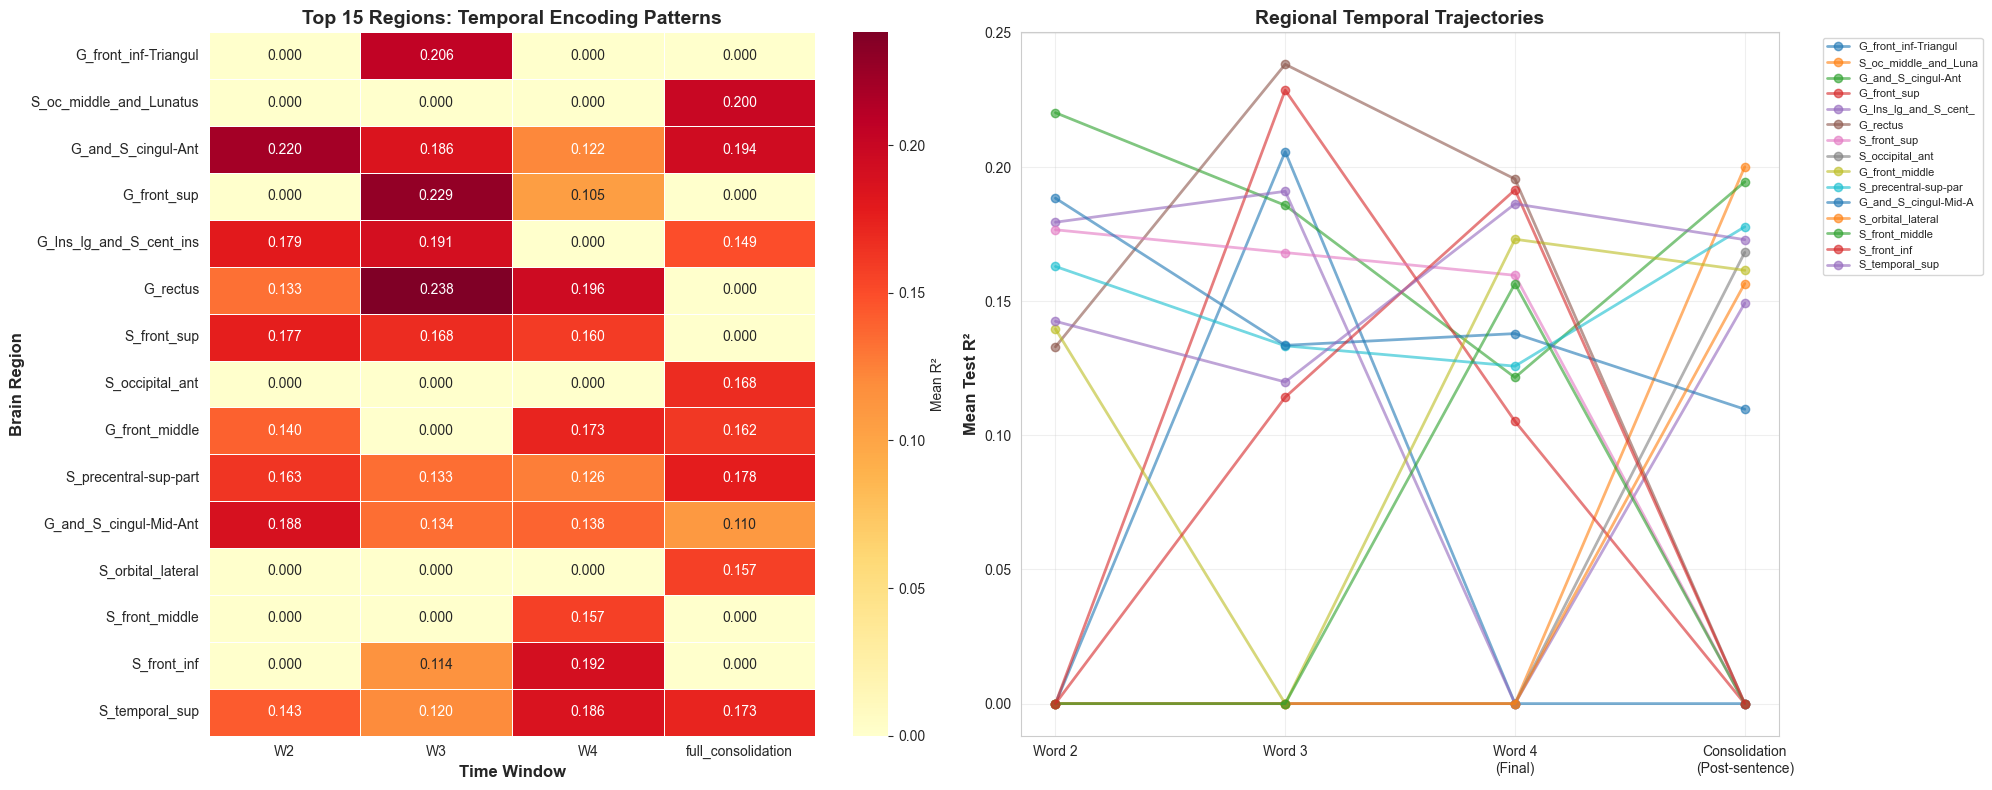

In [ ]:
def plot_regional_temporal_dynamics(df, top_n=TOP_N_REGIONS, save_path=None):
    """
    Show how different brain regions encode over time (macro-level view)
    """
    # Get top regions by average R²
    top_regions = df.groupby('parcLabel')['test_R_2'].mean().nlargest(top_n).index
    
    # Filter data
    region_data = df[df['parcLabel'].isin(top_regions)]
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Heatmap of region by time window
    pivot = region_data.groupby(['parcLabel', 'time_window'])['test_R_2'].mean().unstack(fill_value=0)
    pivot = pivot.reindex(columns=TIME_WINDOWS)
    pivot = pivot.reindex(top_regions)  # Order by overall performance
    
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', 
                cbar_kws={'label': 'Mean R²'},
                linewidths=0.5, ax=ax1)
    ax1.set_xlabel('Time Window', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Brain Region', fontsize=12, fontweight='bold')
    ax1.set_title(f'Top {top_n} Regions: Temporal Encoding Patterns', 
                 fontsize=14, fontweight='bold')
    
    # 2. Line plot showing trajectories
    for region in top_regions:
        region_vals = pivot.loc[region]
        ax2.plot(range(len(TIME_WINDOWS)), region_vals.values, 
                marker='o', linewidth=2, alpha=0.6, label=region[:20])
    
    ax2.set_xticks(range(len(TIME_WINDOWS)))
    ax2.set_xticklabels([TIME_WINDOW_LABELS[tw] for tw in TIME_WINDOWS], fontsize=10)
    ax2.set_ylabel('Mean Test R²', fontsize=12, fontweight='bold')
    ax2.set_title('Regional Temporal Trajectories', fontsize=14, fontweight='bold')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return fig


# Generate regional dynamics
plot_regional_temporal_dynamics(
    sig_df,
    top_n=15,
    save_path='figures/time_window_viz/regional_analysis/temporal_heatmap.png'
)

## 5. Brain Region Analysis with Time Windows

### 5.1 Top Regions by Time Window

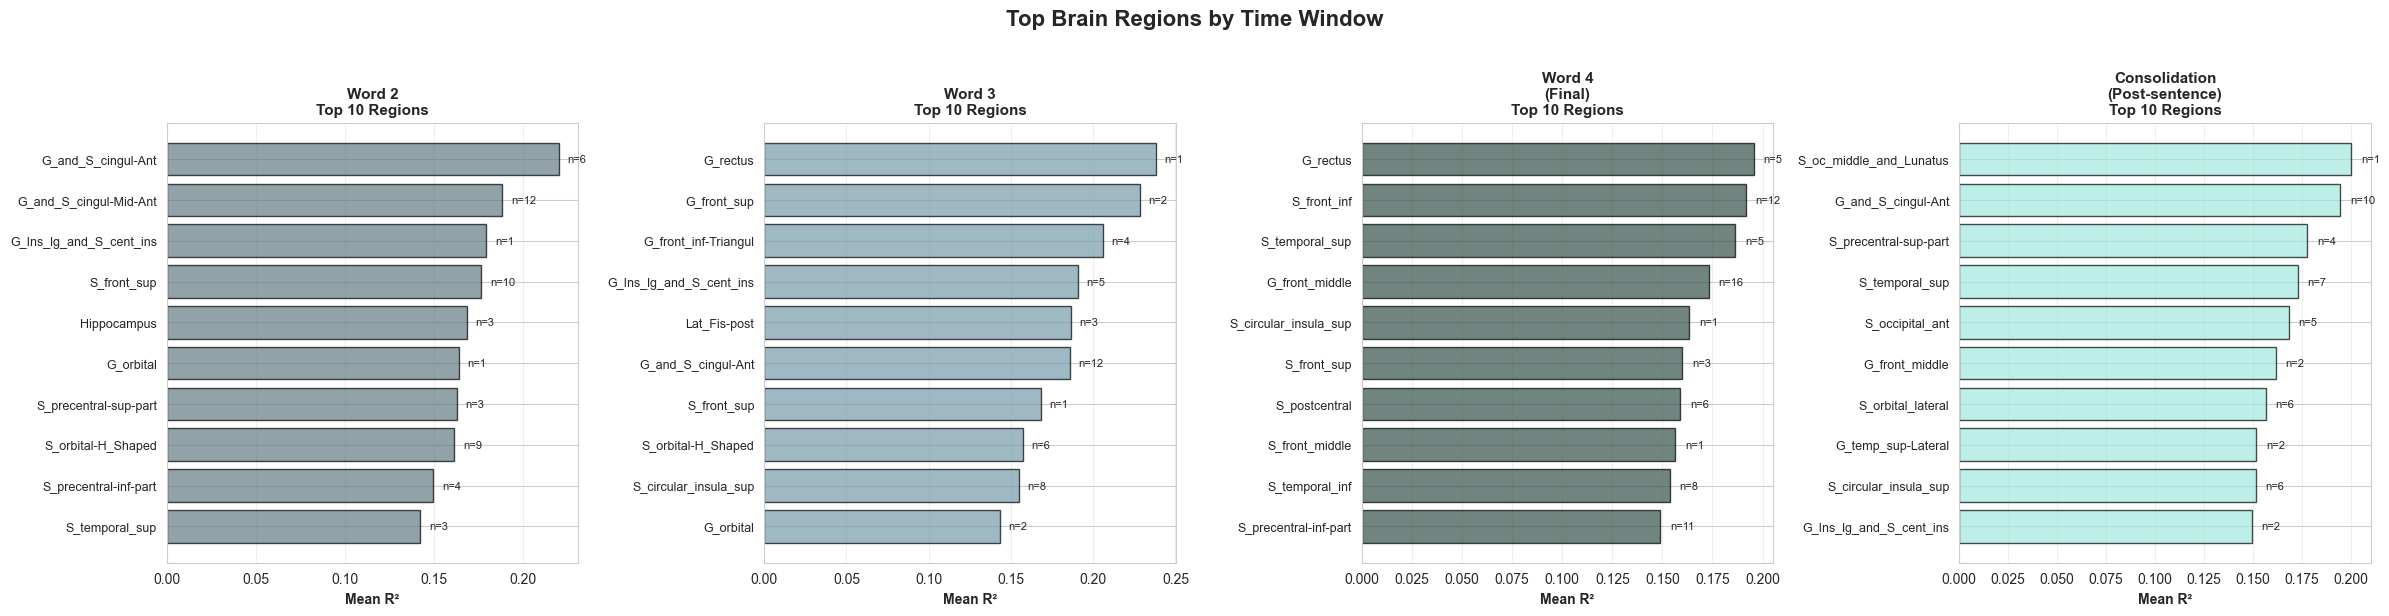


TOP REGIONS BY TIME WINDOW

W2 (Word 2)
------------------------------------------------------------
  1. G_and_S_cingul-Ant                       | R²=0.2203 (n=6)
  2. G_and_S_cingul-Mid-Ant                   | R²=0.1884 (n=12)
  3. G_Ins_lg_and_S_cent_ins                  | R²=0.1794 (n=1)

W3 (Word 3)
------------------------------------------------------------
  1. G_rectus                                 | R²=0.2383 (n=1)
  2. G_front_sup                              | R²=0.2287 (n=2)
  3. G_front_inf-Triangul                     | R²=0.2057 (n=4)

W4 (Word 4 (Final))
------------------------------------------------------------
  1. G_rectus                                 | R²=0.1955 (n=5)
  2. S_front_inf                              | R²=0.1915 (n=12)
  3. S_temporal_sup                           | R²=0.1863 (n=5)

full_consolidation (Consolidation (Post-sentence))
------------------------------------------------------------
  1. S_oc_middle_and_Lunatus                  | R²=

In [92]:
def analyze_regions_by_time_window(df, save_dir=None):
    """
    Identify which regions are most active in each time window
    """
    fig, axes = plt.subplots(1, len(TIME_WINDOWS), figsize=(24, 6))
    
    for idx, tw in enumerate(TIME_WINDOWS):
        ax = axes[idx]
        
        # Get top regions for this time window
        tw_data = df[df['time_window'] == tw]
        top_regions = tw_data.groupby('parcLabel')['test_R_2'].agg(['mean', 'count']).nlargest(10, 'mean')
        
        # Plot
        y_pos = np.arange(len(top_regions))
        ax.barh(y_pos, top_regions['mean'].values, 
               color=TIME_WINDOW_COLORS[tw], alpha=0.7, edgecolor='black')
        
        # Add count labels
        for i, (region, row) in enumerate(top_regions.iterrows()):
            ax.text(row['mean'] + 0.005, i, f"n={int(row['count'])}",
                   va='center', fontsize=8)
        
        ax.set_yticks(y_pos)
        ax.set_yticklabels([r[:25] for r in top_regions.index], fontsize=9)
        ax.set_xlabel('Mean R²', fontsize=10, fontweight='bold')
        ax.set_title(f'{TIME_WINDOW_LABELS[tw]}\nTop 10 Regions', 
                    fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        
        # Invert y-axis so best is at top
        ax.invert_yaxis()
    
    plt.suptitle('Top Brain Regions by Time Window', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_dir:
        plt.savefig(f'{save_dir}/top_regions_by_window.png', dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Print summary
    print("\n" + "="*80)
    print("TOP REGIONS BY TIME WINDOW")
    print("="*80)
    
    for tw in TIME_WINDOWS:
        tw_data = df[df['time_window'] == tw]
        top_3 = tw_data.groupby('parcLabel')['test_R_2'].mean().nlargest(3)
        
        print(f"\n{tw} ({TIME_WINDOW_LABELS[tw].replace(chr(10), ' ')})")
        print("-" * 60)
        for i, (region, r2) in enumerate(top_3.items(), 1):
            count = len(tw_data[tw_data['parcLabel'] == region])
            print(f"  {i}. {region[:40]:40s} | R²={r2:.4f} (n={count})")


# Run analysis
analyze_regions_by_time_window(
    sig_df,
    save_dir='figures/time_window_viz/regional_analysis'
)

### 5.2 Temporal Specialization Analysis

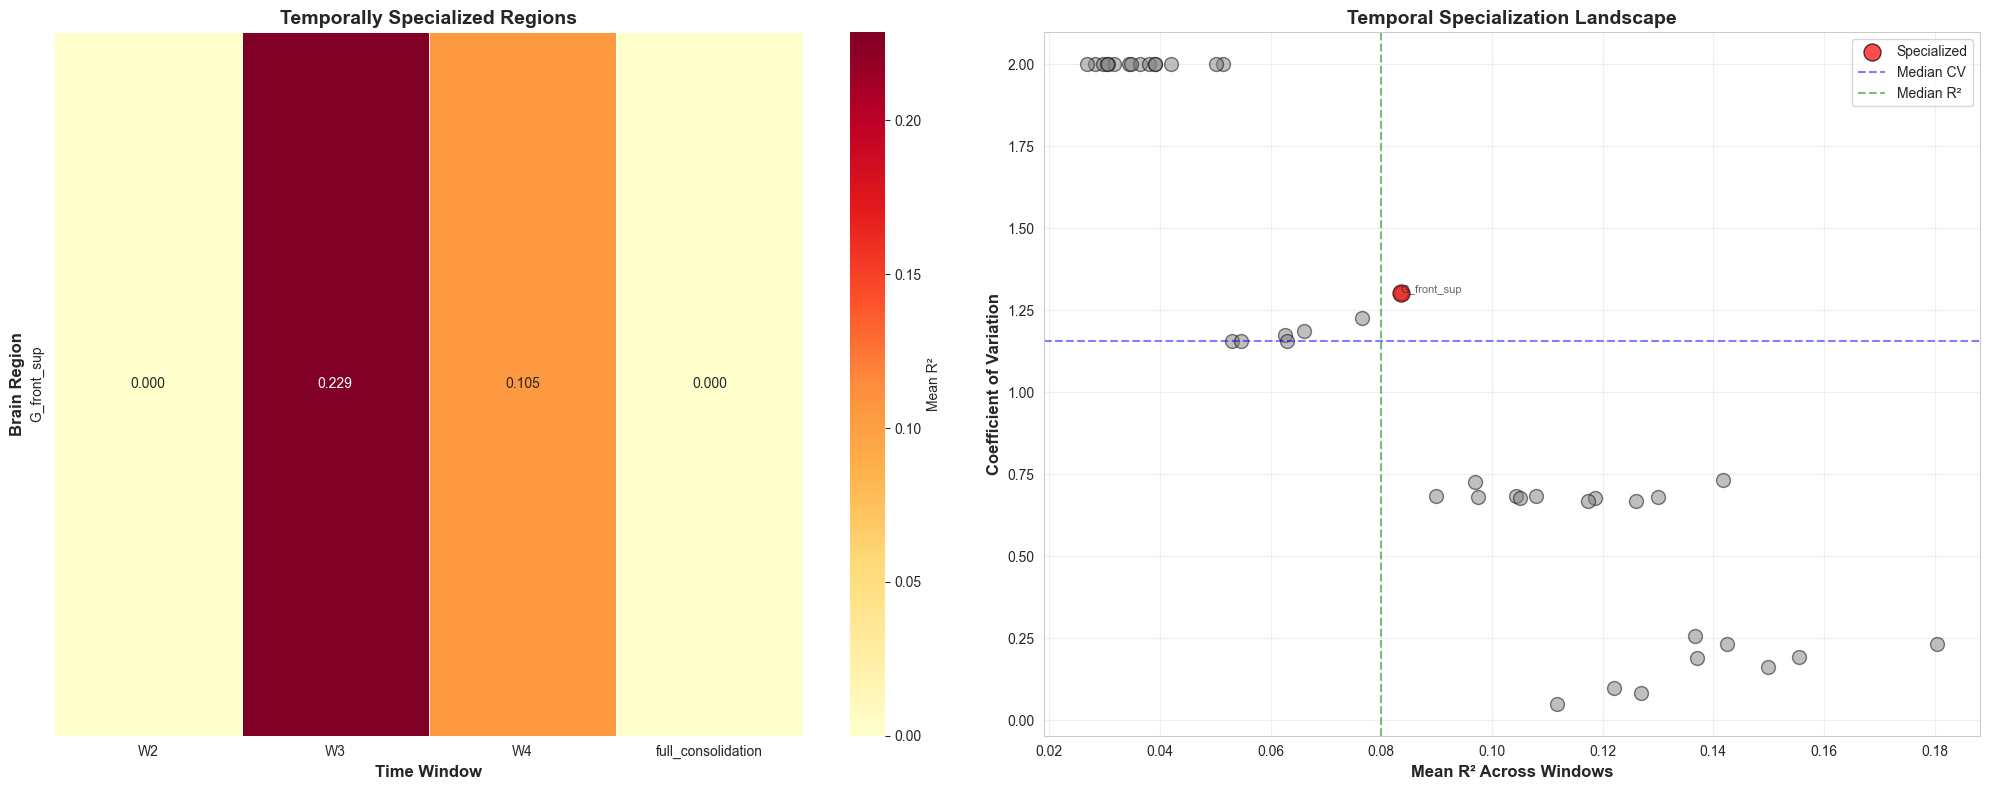


TEMPORALLY SPECIALIZED REGIONS

Regions showing strong preference for specific time windows:

G_front_sup                             
  Best window: W3                   (R² = 0.2287)
  Mean R²: 0.0835  |  CV: 1.303  |  Range: 0.2287



In [ ]:
def find_temporally_specialized_regions(df, save_path=None):
    """
    Identify regions that specialize in specific time windows
    (high performance in one window, lower in others)
    """
    # Calculate variance in R² across time windows for each region
    region_stats = df.groupby(['parcLabel', 'time_window'])['test_R_2'].mean().unstack(fill_value=0)
    region_stats = region_stats.reindex(columns=TIME_WINDOWS)
    
    # Calculate specialization metrics
    region_stats['mean'] = region_stats.mean(axis=1)
    region_stats['std'] = region_stats[TIME_WINDOWS].std(axis=1)
    region_stats['max'] = region_stats[TIME_WINDOWS].max(axis=1)
    region_stats['min'] = region_stats[TIME_WINDOWS].min(axis=1)
    region_stats['range'] = region_stats['max'] - region_stats['min']
    region_stats['cv'] = region_stats['std'] / region_stats['mean']  # Coefficient of variation
    region_stats['best_window'] = region_stats[TIME_WINDOWS].idxmax(axis=1)
    
    # Find specialized regions->high CV and high mean 
    specialized = region_stats[
        (region_stats['cv'] > region_stats['cv'].median()) & 
        (region_stats['mean'] > region_stats['mean'].median())
    ].sort_values('cv', ascending=False).head(15)
    
    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Heatmap of specialized regions
    specialized_data = specialized[TIME_WINDOWS]
    sns.heatmap(specialized_data, annot=True, fmt='.3f', cmap='YlOrRd',
               cbar_kws={'label': 'Mean R²'},
               linewidths=0.5, ax=ax1)
    ax1.set_xlabel('Time Window', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Brain Region', fontsize=12, fontweight='bold')
    ax1.set_title('Temporally Specialized Regions', fontsize=14, fontweight='bold')
    
    # 2. Specialization scatter
    ax2.scatter(region_stats['mean'], region_stats['cv'], 
               alpha=0.5, s=100, c='gray', edgecolor='black')
    ax2.scatter(specialized['mean'], specialized['cv'],
               alpha=0.7, s=150, c='red', edgecolor='black', label='Specialized')
    
    # Label specialized regions
    for region, row in specialized.head(8).iterrows():
        ax2.annotate(region[:20], (row['mean'], row['cv']),
                    fontsize=8, alpha=0.7)
    
    ax2.axhline(region_stats['cv'].median(), color='blue', linestyle='--', 
               alpha=0.5, label='Median CV')
    ax2.axvline(region_stats['mean'].median(), color='green', linestyle='--',
               alpha=0.5, label='Median R²')
    
    ax2.set_xlabel('Mean R² Across Windows', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Coefficient of Variation', fontsize=12, fontweight='bold')
    ax2.set_title('Temporal Specialization Landscape', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Print specialized regions
    print("\n" + "="*80)
    print("TEMPORALLY SPECIALIZED REGIONS")
    print("="*80)
    print("\nRegions showing strong preference for specific time windows:\n")
    
    for region, row in specialized.head(10).iterrows():
        print(f"{region:40s}")
        print(f"  Best window: {row['best_window']:20s} (R² = {row['max']:.4f})")
        print(f"  Mean R²: {row['mean']:.4f}  |  CV: {row['cv']:.3f}  |  Range: {row['range']:.4f}")
        print()
    
    return specialized


# Find specialized regions
specialized_regions = find_temporally_specialized_regions(
    sig_df,
    save_path='figures/time_window_viz/regional_analysis/specialized_regions.png'
)

## 6. Hemisphere Comparison Across Time

W2: Left vs Right, p=0.1257
W3: Left vs Right, p=0.6474
W4: Left vs Right, p=0.1072
full_consolidation: Left vs Right, p=0.0153


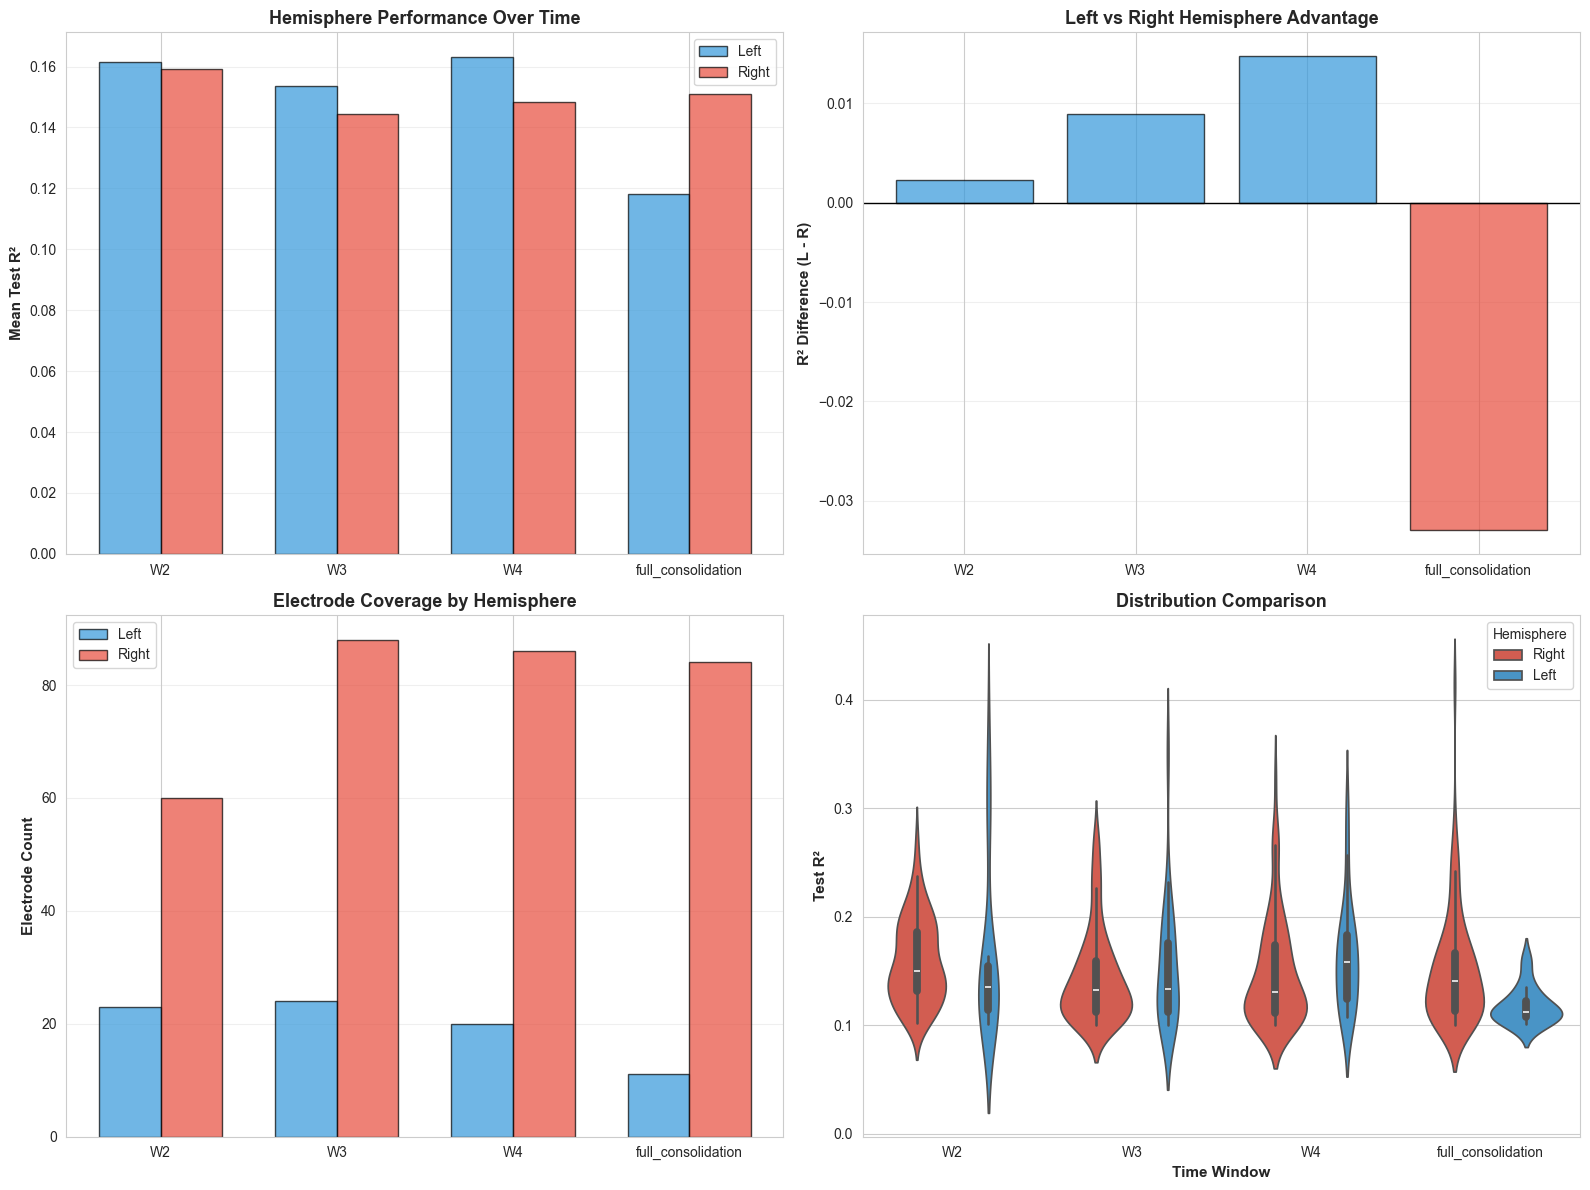

In [94]:
def analyze_hemisphere_temporal_dynamics(df, save_path=None):
    """
    Compare left vs right hemisphere encoding over time
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Overall hemisphere comparison
    ax = axes[0, 0]
    hemi_data = df.groupby(['hemisphere', 'time_window'])['test_R_2'].mean().unstack()
    hemi_data = hemi_data.reindex(columns=TIME_WINDOWS)
    
    x = np.arange(len(TIME_WINDOWS))
    width = 0.35
    
    ax.bar(x - width/2, hemi_data.loc['Left'], width, label='Left', 
          color='#3498db', alpha=0.7, edgecolor='black')
    ax.bar(x + width/2, hemi_data.loc['Right'], width, label='Right',
          color='#e74c3c', alpha=0.7, edgecolor='black')
    
    ax.set_xticks(x)
    ax.set_xticklabels([tw for tw in TIME_WINDOWS], fontsize=10)
    ax.set_ylabel('Mean Test R²', fontsize=11, fontweight='bold')
    ax.set_title('Hemisphere Performance Over Time', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    # 2. Difference plot
    ax = axes[0, 1]
    diff = hemi_data.loc['Left'] - hemi_data.loc['Right']
    colors = ['#3498db' if d > 0 else '#e74c3c' for d in diff]
    
    ax.bar(x, diff, color=colors, alpha=0.7, edgecolor='black')
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels([tw for tw in TIME_WINDOWS], fontsize=10)
    ax.set_ylabel('R² Difference (L - R)', fontsize=11, fontweight='bold')
    ax.set_title('Left vs Right Hemisphere Advantage', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 3. Electrode count comparison
    ax = axes[1, 0]
    hemi_counts = df.groupby(['hemisphere', 'time_window']).size().unstack()
    hemi_counts = hemi_counts.reindex(columns=TIME_WINDOWS)
    
    ax.bar(x - width/2, hemi_counts.loc['Left'], width, label='Left',
          color='#3498db', alpha=0.7, edgecolor='black')
    ax.bar(x + width/2, hemi_counts.loc['Right'], width, label='Right',
          color='#e74c3c', alpha=0.7, edgecolor='black')
    
    ax.set_xticks(x)
    ax.set_xticklabels([tw for tw in TIME_WINDOWS], fontsize=10)
    ax.set_ylabel('Electrode Count', fontsize=11, fontweight='bold')
    ax.set_title('Electrode Coverage by Hemisphere', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    # 4. Distribution comparison
    ax = axes[1, 1]
    for tw in TIME_WINDOWS:
        left_data = df[(df['hemisphere'] == 'Left') & (df['time_window'] == tw)]['test_R_2']
        right_data = df[(df['hemisphere'] == 'Right') & (df['time_window'] == tw)]['test_R_2']
        
        # Statistical test
        if len(left_data) > 0 and len(right_data) > 0:
            stat, p = mannwhitneyu(left_data, right_data)
            print(f"{tw}: Left vs Right, p={p:.4f}")
    
    sns.violinplot(data=df, x='time_window', y='test_R_2', hue='hemisphere',
                  ax=ax, palette={'Left': '#3498db', 'Right': '#e74c3c'},
                  order=TIME_WINDOWS)
    ax.set_xlabel('Time Window', fontsize=11, fontweight='bold')
    ax.set_ylabel('Test R²', fontsize=11, fontweight='bold')
    ax.set_title('Distribution Comparison', fontsize=13, fontweight='bold')
    ax.legend(title='Hemisphere', fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()


# Analyze hemispheres
analyze_hemisphere_temporal_dynamics(
    sig_df,
    save_path='figures/time_window_viz/hemisphere_temporal_comparison.png'
)

## 7. Condition × Time Window Interaction

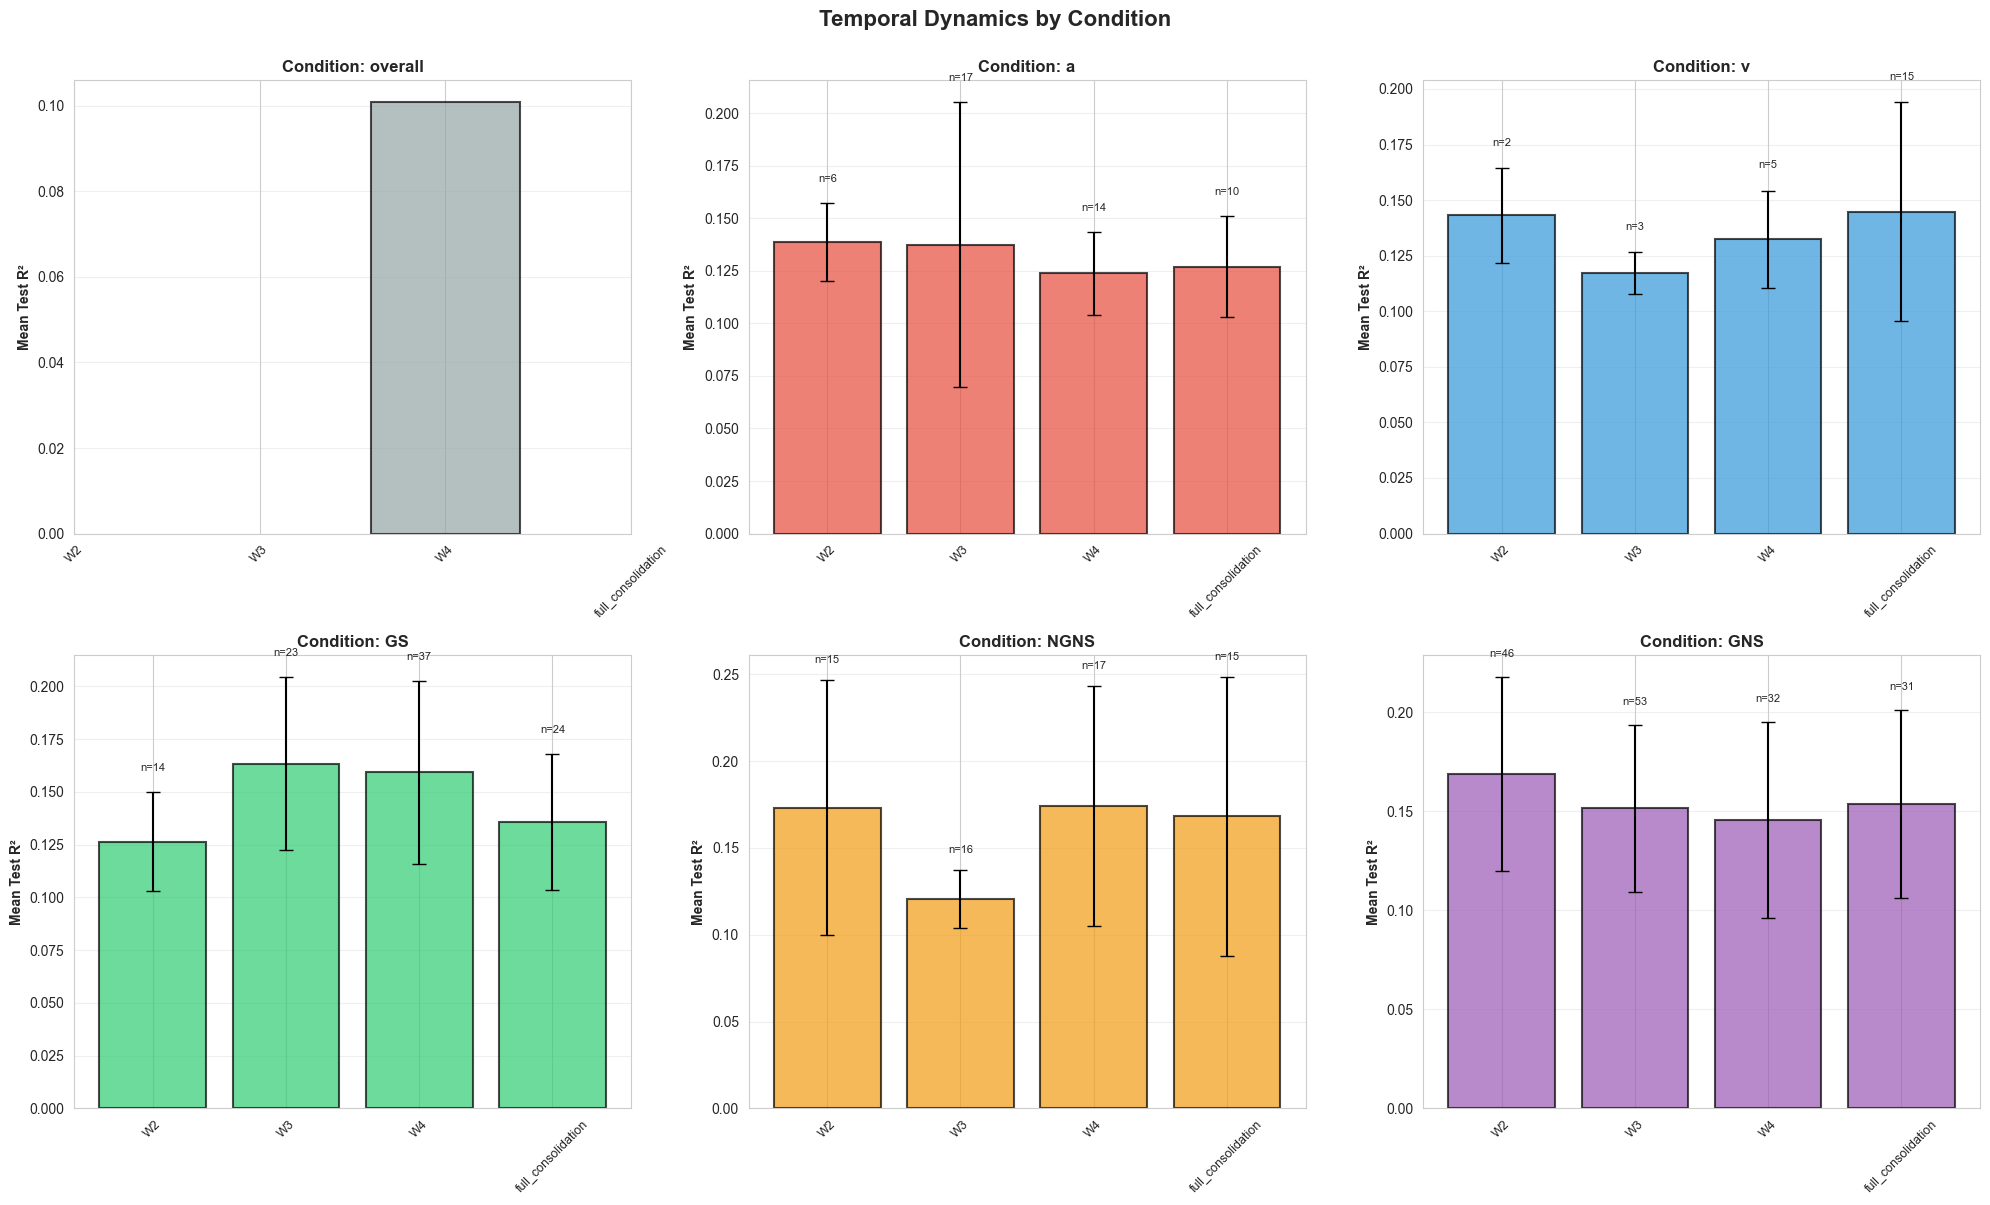


CONDITION × TIME WINDOW SUMMARY

OVERALL:
  W4                  : Mean=0.1009, SD=nan, n=1

A:
  W2                  : Mean=0.1387, SD=0.0184, n=6
  W3                  : Mean=0.1375, SD=0.0679, n=17
  W4                  : Mean=0.1239, SD=0.0198, n=14
  full_consolidation  : Mean=0.1270, SD=0.0242, n=10

V:
  W2                  : Mean=0.1432, SD=0.0213, n=2
  W3                  : Mean=0.1171, SD=0.0094, n=3
  W4                  : Mean=0.1324, SD=0.0218, n=5
  full_consolidation  : Mean=0.1448, SD=0.0493, n=15

GS:
  W2                  : Mean=0.1263, SD=0.0234, n=14
  W3                  : Mean=0.1634, SD=0.0410, n=23
  W4                  : Mean=0.1593, SD=0.0433, n=37
  full_consolidation  : Mean=0.1355, SD=0.0322, n=24

NGNS:
  W2                  : Mean=0.1732, SD=0.0732, n=15
  W3                  : Mean=0.1204, SD=0.0167, n=16
  W4                  : Mean=0.1741, SD=0.0689, n=17
  full_consolidation  : Mean=0.1682, SD=0.0802, n=15

GNS:
  W2                  : Mean=0.1690, S

In [95]:
def analyze_condition_time_interaction(df, save_path=None):
    """
    Analyze how different conditions (a, v, GS, etc.) vary across time
    """
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    
    condition_colors = {
        'overall': '#95a5a6',
        'a': '#e74c3c',
        'v': '#3498db',
        'GS': '#2ecc71',
        'NGNS': '#f39c12',
        'GNS': '#9b59b6'
    }
    
    for idx, condition in enumerate(CONDITIONS):
        ax = axes[idx]
        
        cond_data = df[df['condition'] == condition]
        temporal_profile = cond_data.groupby('time_window')['test_R_2'].agg(['mean', 'std', 'count'])
        temporal_profile = temporal_profile.reindex(TIME_WINDOWS)
        
        x = np.arange(len(TIME_WINDOWS))
        
        # Bar plot with error bars
        ax.bar(x, temporal_profile['mean'], 
              yerr=temporal_profile['std'],
              color=condition_colors[condition],
              alpha=0.7, capsize=5, edgecolor='black', linewidth=1.5)
        
        # Add count labels
        for i, (tw, row) in enumerate(temporal_profile.iterrows()):
            if not np.isnan(row['mean']):
                ax.text(i, row['mean'] + row['std'] + 0.01,
                       f"n={int(row['count'])}",
                       ha='center', fontsize=8)
        
        ax.set_xticks(x)
        ax.set_xticklabels([tw for tw in TIME_WINDOWS], fontsize=9, rotation=45)
        ax.set_ylabel('Mean Test R²', fontsize=10, fontweight='bold')
        ax.set_title(f'Condition: {condition}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Temporal Dynamics by Condition', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Summary statistics
    print("\n" + "="*80)
    print("CONDITION × TIME WINDOW SUMMARY")
    print("="*80)
    
    for condition in CONDITIONS:
        cond_data = df[df['condition'] == condition]
        print(f"\n{condition.upper()}:")
        
        for tw in TIME_WINDOWS:
            tw_data = cond_data[cond_data['time_window'] == tw]['test_R_2']
            if len(tw_data) > 0:
                print(f"  {tw:20s}: Mean={tw_data.mean():.4f}, SD={tw_data.std():.4f}, n={len(tw_data)}")


# Analyze condition × time interaction
analyze_condition_time_interaction(
    sig_df,
    save_path='figures/time_window_viz/condition_time_interaction.png'
)

## 8. Subject-Level Analysis

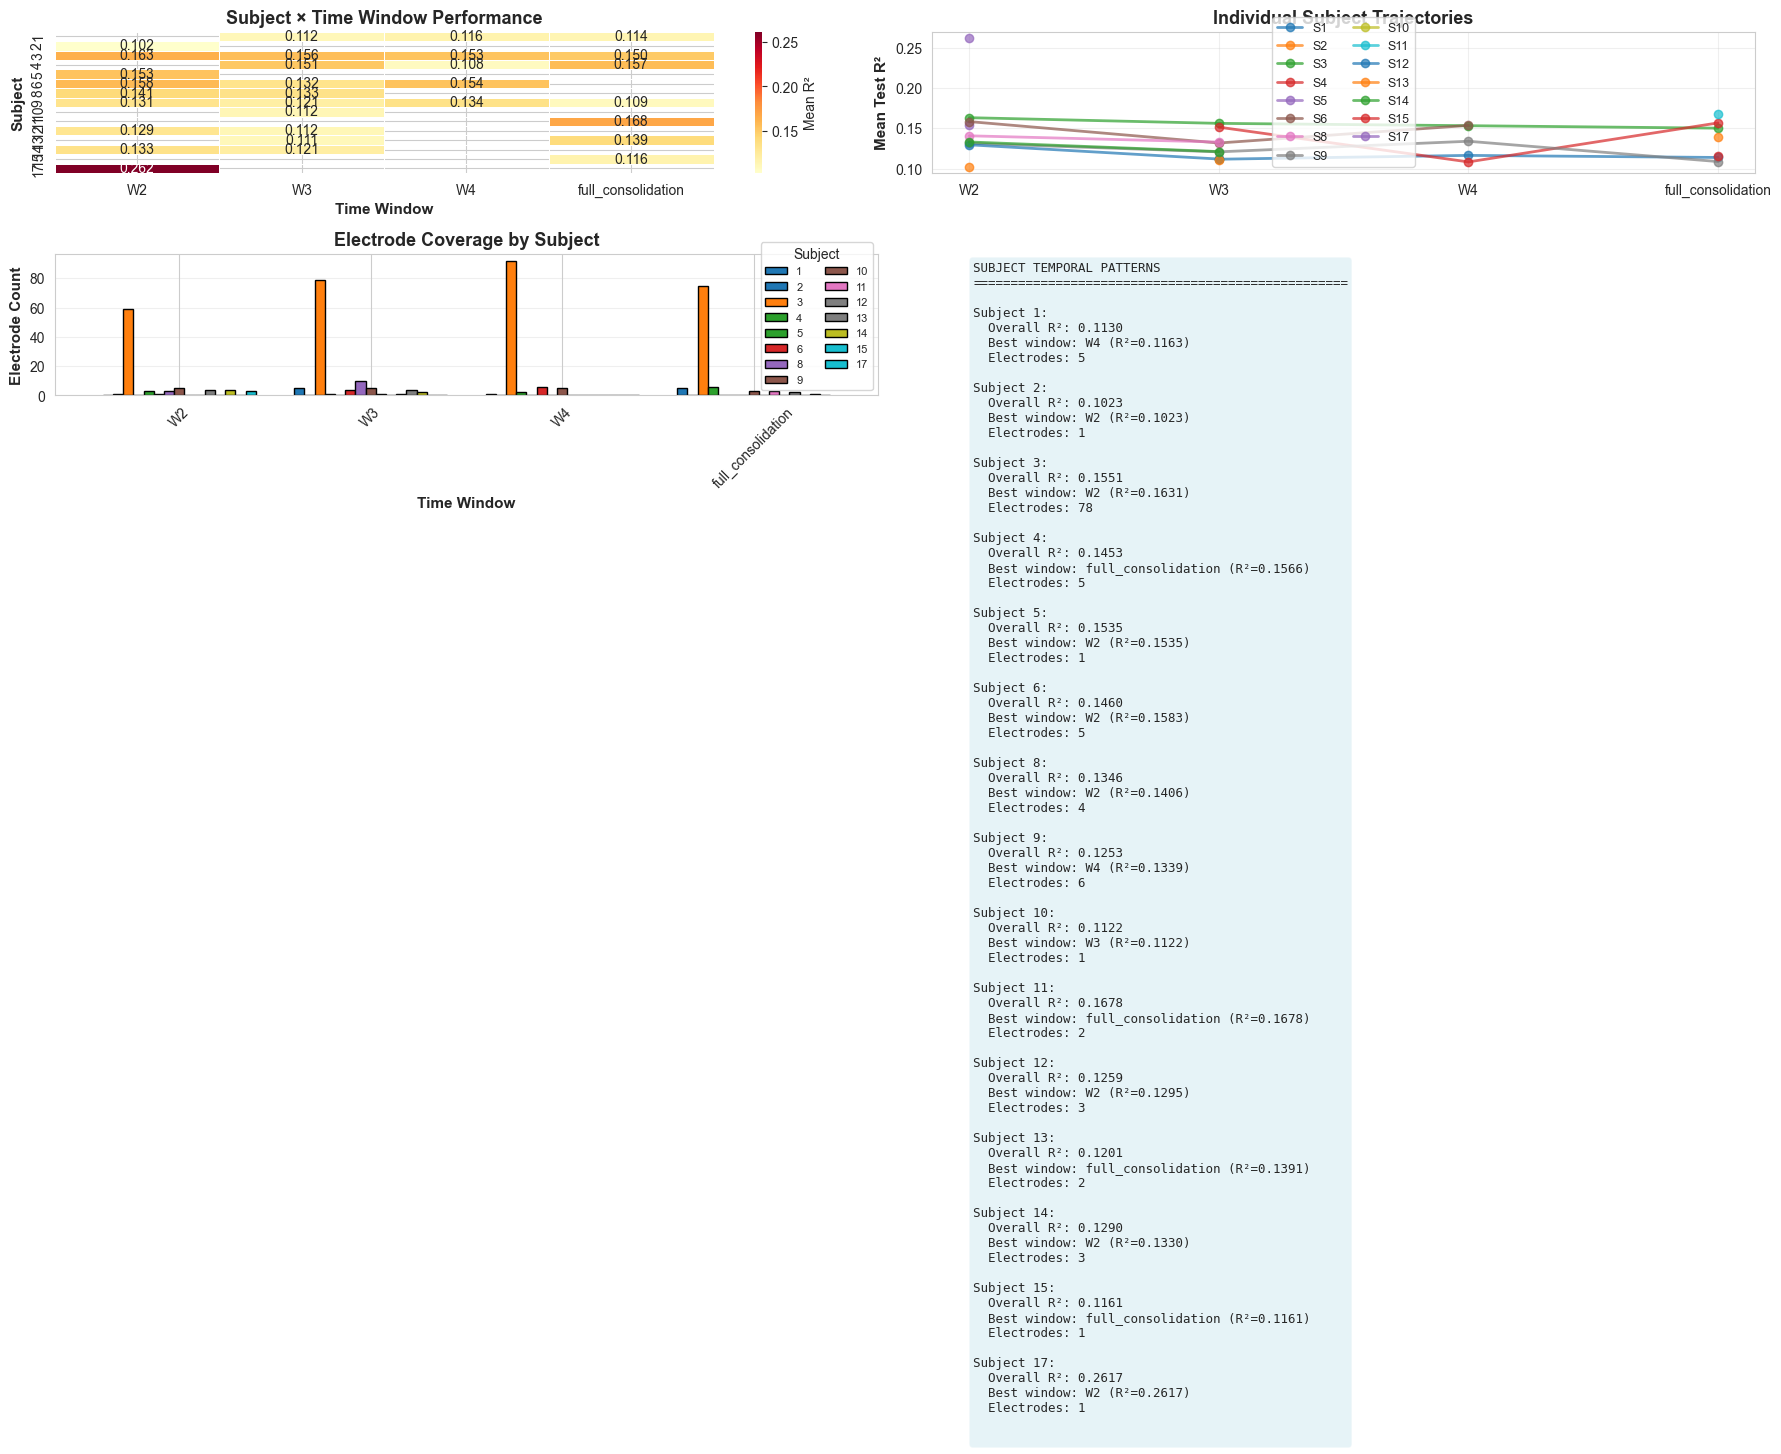

In [ ]:
def analyze_subject_temporal_patterns(df, save_path=None):
    """
    Compare temporal patterns across subjects
    """
    subjects = sorted(df['subject'].unique())
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Subject heatmap
    ax = axes[0, 0]
    subject_time = df.groupby(['subject', 'time_window'])['test_R_2'].mean().unstack()
    subject_time = subject_time.reindex(columns=TIME_WINDOWS)
    
    sns.heatmap(subject_time, annot=True, fmt='.3f', cmap='YlOrRd',
               cbar_kws={'label': 'Mean R²'},
               linewidths=0.5, ax=ax)
    ax.set_xlabel('Time Window', fontsize=11, fontweight='bold')
    ax.set_ylabel('Subject', fontsize=11, fontweight='bold')
    ax.set_title('Subject × Time Window Performance', fontsize=13, fontweight='bold')
    
    # Subject trajectories
    ax = axes[0, 1]
    x = np.arange(len(TIME_WINDOWS))
    
    for subject in subjects:
        subj_data = subject_time.loc[subject]
        ax.plot(x, subj_data.values, marker='o', linewidth=2,
               alpha=0.7, label=f'S{subject}')
    
    ax.set_xticks(x)
    ax.set_xticklabels([tw for tw in TIME_WINDOWS], fontsize=10)
    ax.set_ylabel('Mean Test R²', fontsize=11, fontweight='bold')
    ax.set_title('Individual Subject Trajectories', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)
    
    #Electrode counts per subject
    ax = axes[1, 0]
    subject_counts = df.groupby(['subject', 'time_window']).size().unstack()
    subject_counts = subject_counts.reindex(columns=TIME_WINDOWS)
    
    subject_counts.T.plot(kind='bar', ax=ax, width=0.8, 
                         colormap='tab10', edgecolor='black')
    ax.set_xlabel('Time Window', fontsize=11, fontweight='bold')
    ax.set_ylabel('Electrode Count', fontsize=11, fontweight='bold')
    ax.set_title('Electrode Coverage by Subject', fontsize=13, fontweight='bold')
    ax.legend(title='Subject', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    
    #Subject stats
    ax = axes[1, 1]
    ax.axis('off')
    
    stats_text = "SUBJECT TEMPORAL PATTERNS\n" + "="*50 + "\n\n"
    
    for subject in subjects:
        subj_data = df[df['subject'] == subject]
        
        # Best window
        best_tw = subj_data.groupby('time_window')['test_R_2'].mean().idxmax()
        best_r2 = subj_data.groupby('time_window')['test_R_2'].mean().max()
        
        # Overall stats
        mean_r2 = subj_data['test_R_2'].mean()
        n_elec = subj_data['electrode'].nunique()
        
        stats_text += f"Subject {subject}:\n"
        stats_text += f"  Overall R²: {mean_r2:.4f}\n"
        stats_text += f"  Best window: {best_tw} (R²={best_r2:.4f})\n"
        stats_text += f"  Electrodes: {n_elec}\n\n"
    
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
           fontsize=9, verticalalignment='top', family='monospace',
           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()


# Analyze subjects
analyze_subject_temporal_patterns(
    sig_df,
    save_path='figures/time_window_viz/subject_temporal_patterns.png'
)

## 9. Summary Statistics Export

In [ ]:

print("Generating summary statistics...")


time_summary = sig_df.groupby('time_window')['test_R_2'].describe()
time_summary.to_csv('figures/time_window_viz/time_window_summary.csv')
print("✓ Saved: time_window_summary.csv")


region_time_summary = sig_df.groupby(['parcLabel', 'time_window'])['test_R_2'].agg([
    'mean', 'std', 'count'
]).reset_index()
region_time_summary.to_csv('figures/time_window_viz/region_time_summary.csv', index=False)
print("✓ Saved: region_time_summary.csv")


subject_time_summary = sig_df.groupby(['subject', 'time_window'])['test_R_2'].agg([
    'mean', 'std', 'count'
]).reset_index()
subject_time_summary.to_csv('figures/time_window_viz/subject_time_summary.csv', index=False)
print("✓ Saved: subject_time_summary.csv")


model_layer_time_summary = sig_df.groupby(['model', 'layer', 'time_window'])['test_R_2'].agg([
    'mean', 'std', 'count'
]).reset_index()
model_layer_time_summary.to_csv('figures/time_window_viz/model_layer_time_summary.csv', index=False)
print("✓ Saved: model_layer_time_summary.csv")


condition_time_summary = sig_df.groupby(['condition', 'time_window'])['test_R_2'].agg([
    'mean', 'std', 'count'
]).reset_index()
condition_time_summary.to_csv('figures/time_window_viz/condition_time_summary.csv', index=False)
print("✓ Saved: condition_time_summary.csv")

print("\n" + "="*80)
print("ALL VISUALIZATIONS AND SUMMARIES COMPLETE!")
print("="*80)
print(f"\nOutput directories:")
print(f"  - figures/time_window_viz/")
print(f"  - figures/time_window_viz/brain_plots/")
print(f"  - figures/time_window_viz/temporal_dynamics/")
print(f"  - figures/time_window_viz/regional_analysis/")

Generating summary statistics...
✓ Saved: time_window_summary.csv
✓ Saved: region_time_summary.csv
✓ Saved: subject_time_summary.csv
✓ Saved: model_layer_time_summary.csv
✓ Saved: condition_time_summary.csv

ALL VISUALIZATIONS AND SUMMARIES COMPLETE!

Output directories:
  - figures/time_window_viz/
  - figures/time_window_viz/brain_plots/
  - figures/time_window_viz/temporal_dynamics/
  - figures/time_window_viz/regional_analysis/


## 10. Interactive Exploration (Optional)

Use these cells to explore specific aspects of the data interactively.

In [99]:
# Explore specific electrode
def explore_electrode(subject, electrode, df=sig_df):
    """
    Detailed view of a single electrode across time windows
    """
    elec_data = df[(df['subject'] == subject) & (df['electrode'] == electrode)]
    
    if len(elec_data) == 0:
        print(f"No data found for Subject {subject}, Electrode {electrode}")
        return
    
    print(f"\n{'='*80}")
    print(f"ELECTRODE PROFILE: Subject {subject}, Electrode {electrode}")
    print(f"{'='*80}")
    print(f"\nBrain Region: {elec_data['parcLabel'].iloc[0]}")
    print(f"Hemisphere: {elec_data['hemisphere'].iloc[0]}")
    print(f"\nTemporal Profile:")
    
    for tw in TIME_WINDOWS:
        tw_data = elec_data[elec_data['time_window'] == tw]
        if len(tw_data) > 0:
            print(f"\n  {tw} ({TIME_WINDOW_LABELS[tw].replace(chr(10), ' ')}):")
            print(f"    Mean R²: {tw_data['test_R_2'].mean():.4f}")
            print(f"    Records: {len(tw_data)}")
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    temporal_profile = elec_data.groupby('time_window')['test_R_2'].mean().reindex(TIME_WINDOWS)
    x = np.arange(len(TIME_WINDOWS))
    
    ax.bar(x, temporal_profile.values,
          color=[TIME_WINDOW_COLORS[tw] for tw in TIME_WINDOWS],
          alpha=0.7, edgecolor='black', linewidth=2)
    
    ax.set_xticks(x)
    ax.set_xticklabels([TIME_WINDOW_LABELS[tw] for tw in TIME_WINDOWS], fontsize=11)
    ax.set_ylabel('Mean Test R²', fontsize=12, fontweight='bold')
    ax.set_title(f'S{subject} E{electrode} - {elec_data["parcLabel"].iloc[0]}',
                fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

# Example usage:
# explore_electrode(1, 10)

In [100]:
# Explore specific region
def explore_region(region_name, df=sig_df):
    """
    Detailed view of a brain region across time windows
    """
    region_data = df[df['parcLabel'] == region_name]
    
    if len(region_data) == 0:
        print(f"No data found for region: {region_name}")
        return
    
    print(f"\n{'='*80}")
    print(f"REGION PROFILE: {region_name}")
    print(f"{'='*80}")
    print(f"\nTotal electrodes: {region_data['electrode'].nunique()}")
    print(f"Subjects: {sorted(region_data['subject'].unique())}")
    print(f"\nTemporal Profile:")
    
    time_stats = region_data.groupby('time_window')['test_R_2'].agg(['mean', 'std', 'count'])
    time_stats = time_stats.reindex(TIME_WINDOWS)
    
    for tw, row in time_stats.iterrows():
        print(f"  {tw:20s}: Mean={row['mean']:.4f}, SD={row['std']:.4f}, n={int(row['count'])}")
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Temporal profile
    x = np.arange(len(TIME_WINDOWS))
    ax1.bar(x, time_stats['mean'], yerr=time_stats['std'],
           color=[TIME_WINDOW_COLORS[tw] for tw in TIME_WINDOWS],
           alpha=0.7, capsize=5, edgecolor='black', linewidth=2)
    
    ax1.set_xticks(x)
    ax1.set_xticklabels([TIME_WINDOW_LABELS[tw] for tw in TIME_WINDOWS], fontsize=11)
    ax1.set_ylabel('Mean Test R²', fontsize=12, fontweight='bold')
    ax1.set_title(f'{region_name} - Temporal Profile', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Distribution
    sns.violinplot(data=region_data, x='time_window', y='test_R_2',
                  ax=ax2, order=TIME_WINDOWS,
                  palette=TIME_WINDOW_COLORS)
    ax2.set_xlabel('Time Window', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Test R²', fontsize=12, fontweight='bold')
    ax2.set_title('Distribution', fontsize=14, fontweight='bold')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()

Saved: condition_layer_interaction.png


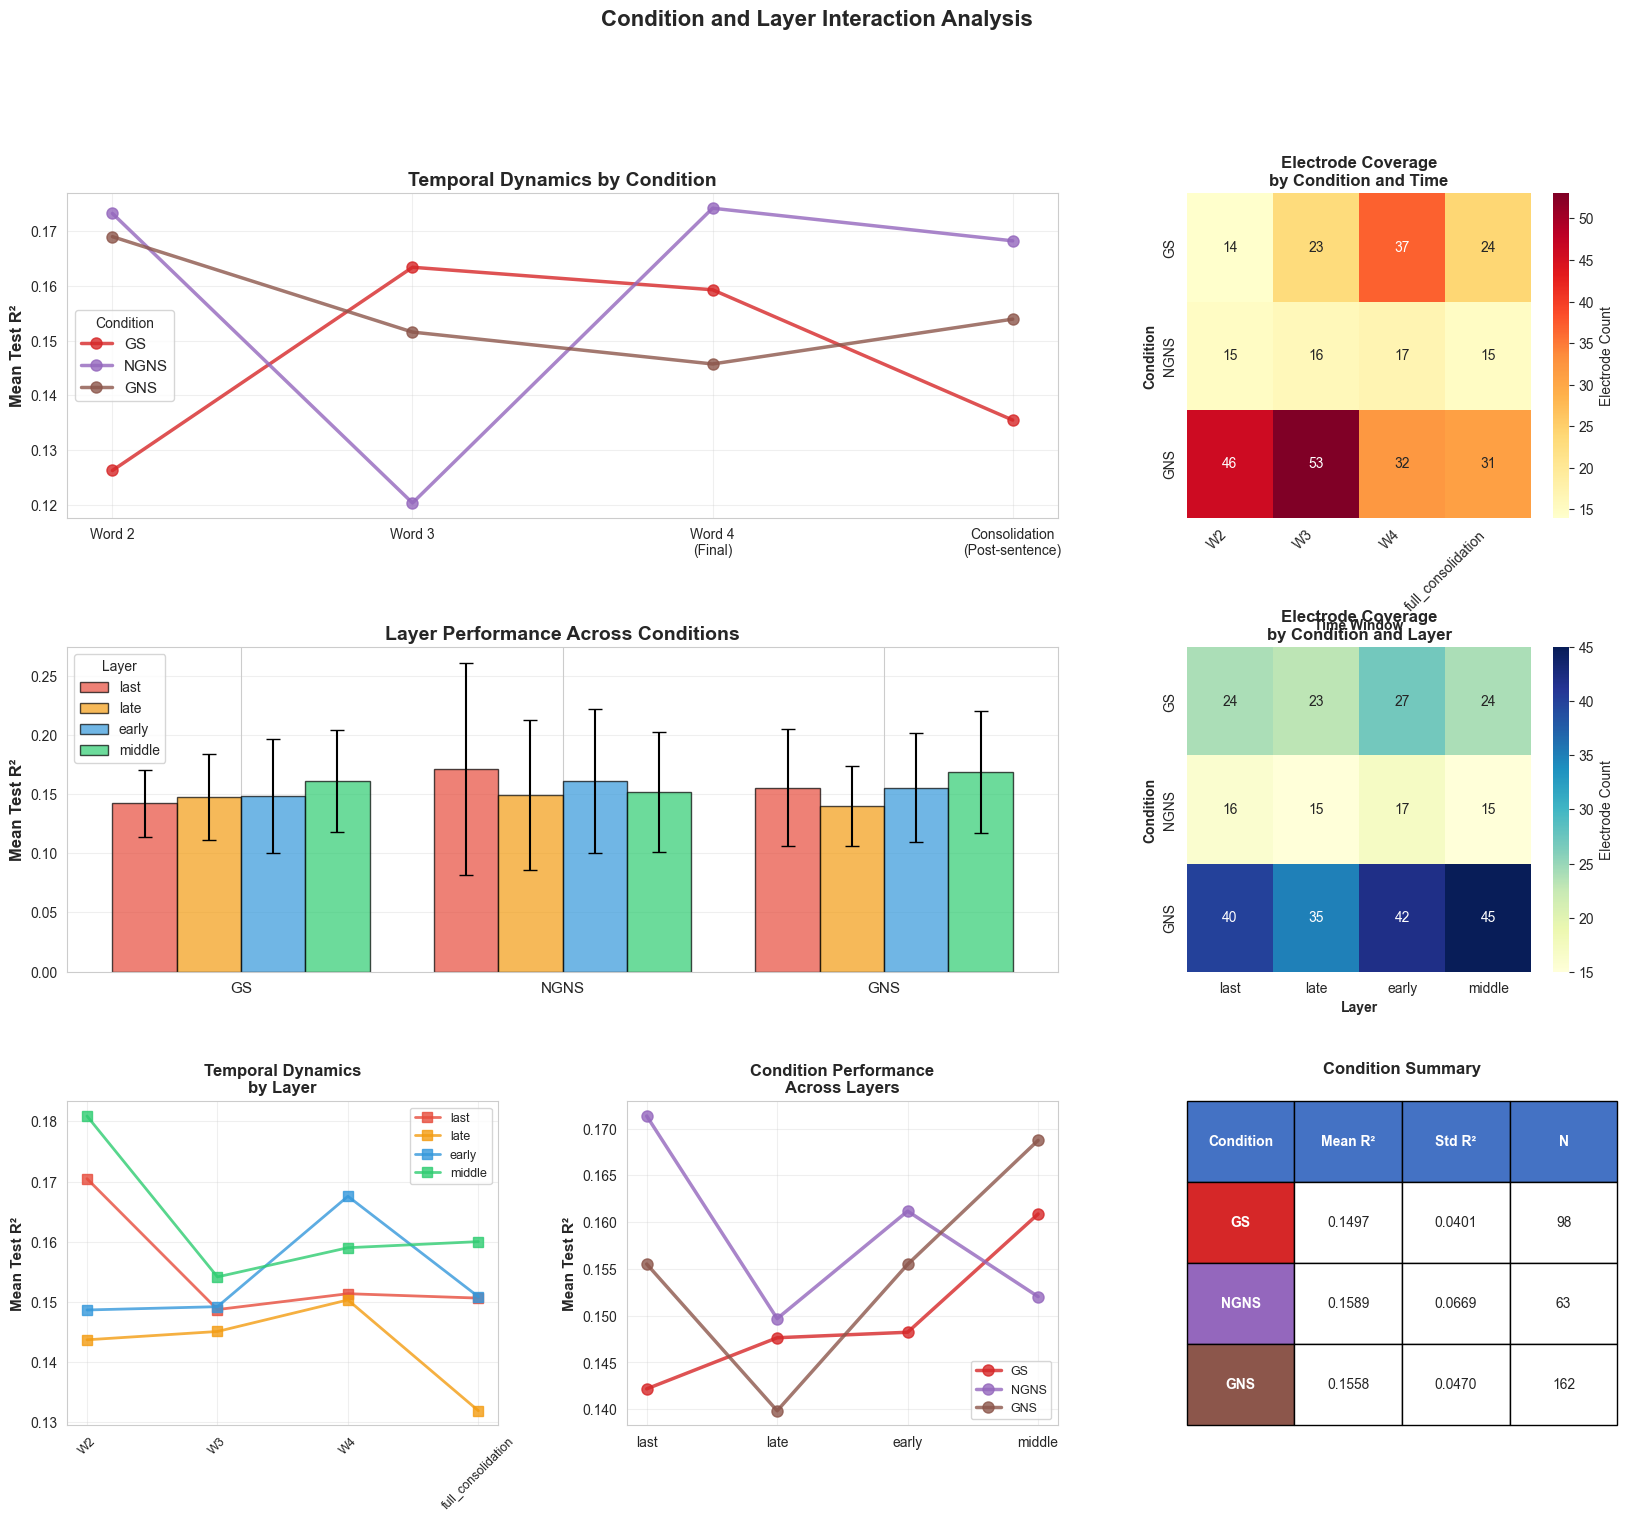

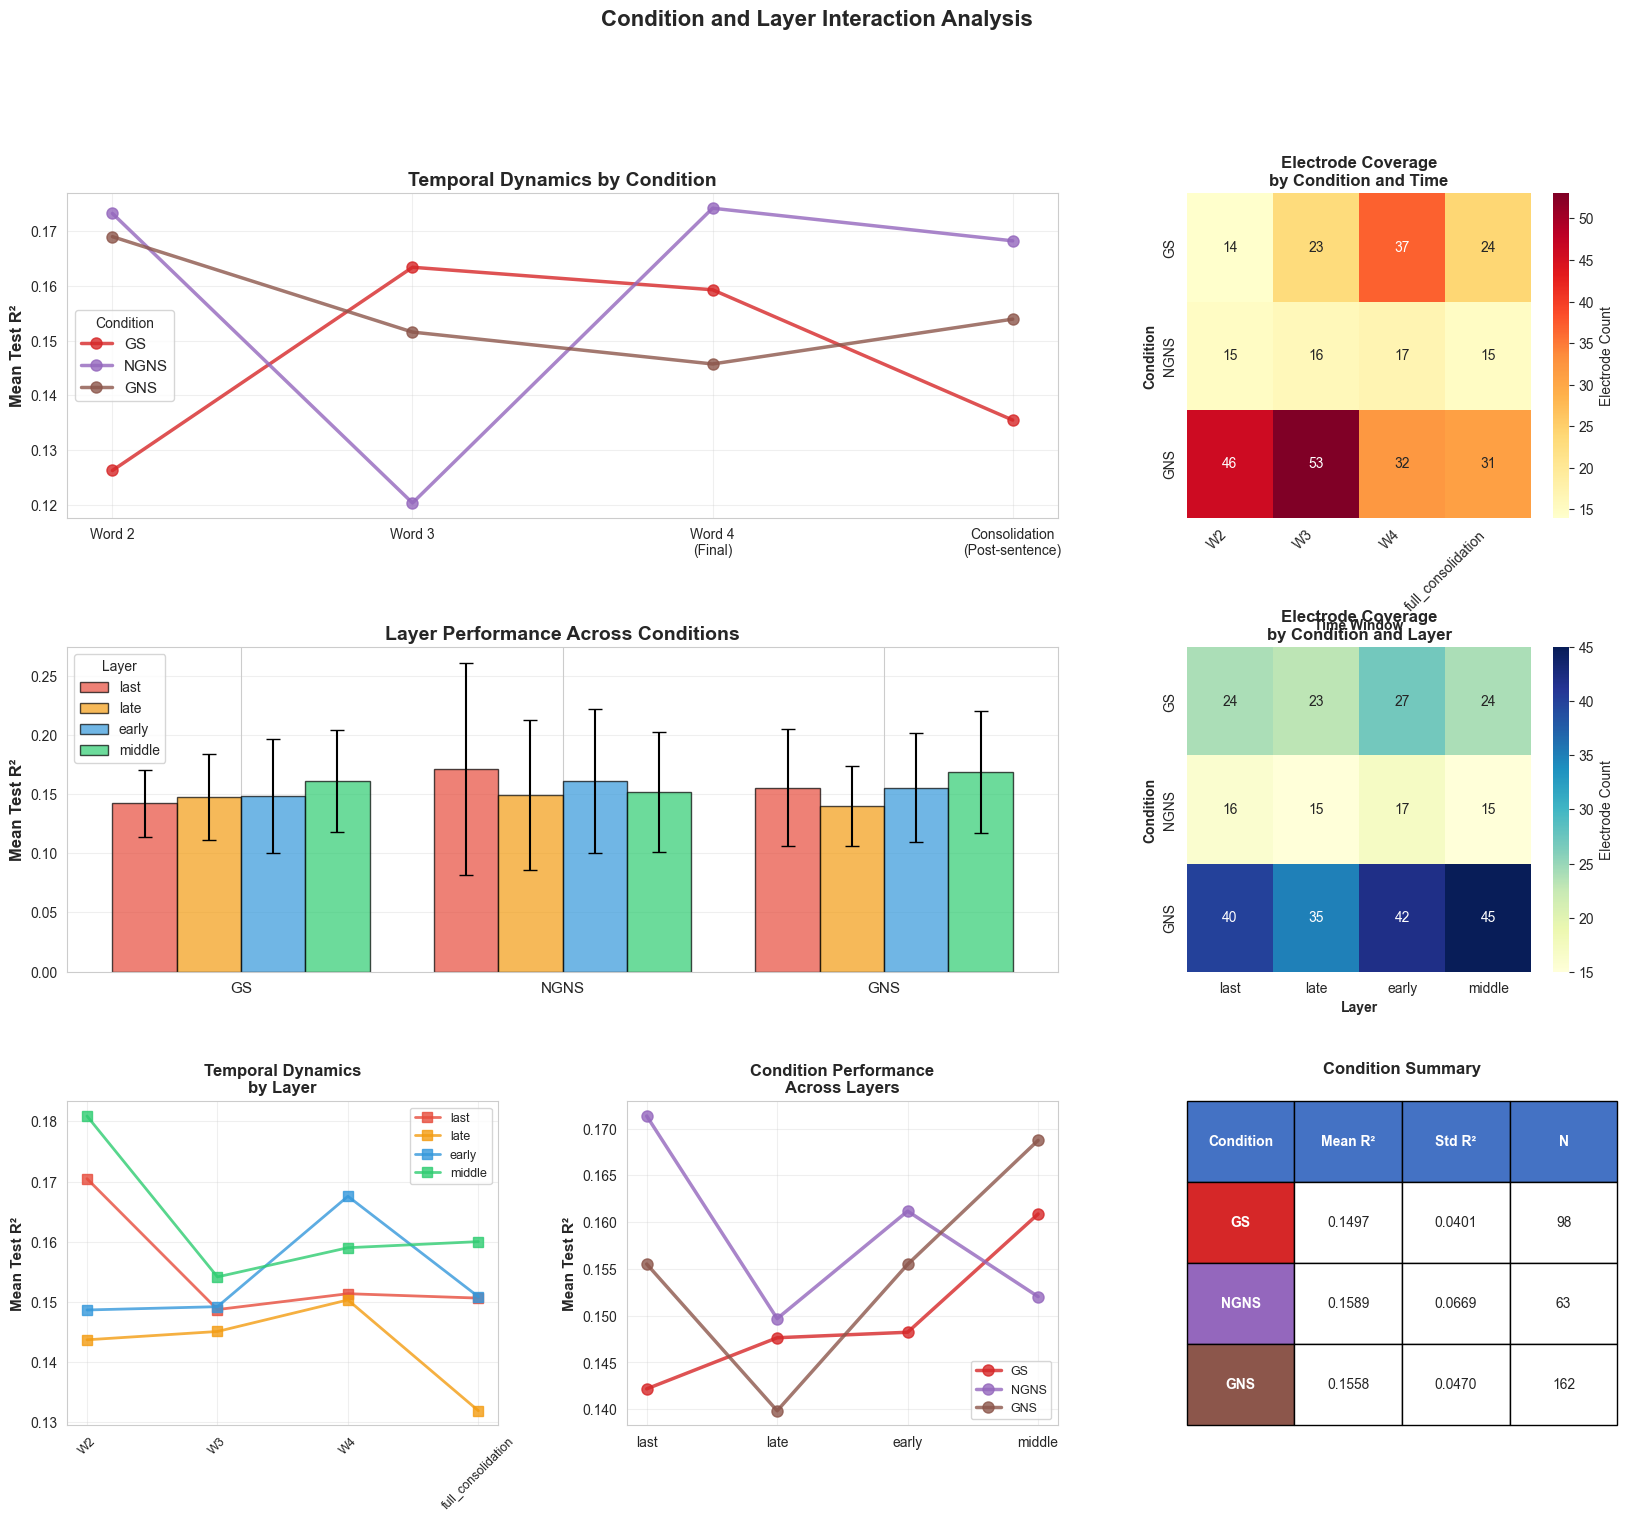

In [ ]:
def plot_condition_layer_interaction(df, save_path=None):
    """
    Analyze performance patterns across conditions and layers
    Shows:
    - Temporal dynamics by condition
    - Layer effects across conditions  
    - Condition-layer interaction patterns
    - Coverage statistics
    """
    CONDITIONS = [ "GS", "NGNS", "GNS"]
    LAYERS = ['last', 'late', 'early', 'middle']
    
    df_filtered = df[df['condition'].isin(CONDITIONS)].copy()
    
    # Define colors
    CONDITION_COLORS = {
        'GS': '#d62728',
        'NGNS': '#9467bd',
        'GNS': '#8c564b'
    }
    
    LAYER_COLORS = {
        'last': '#e74c3c',
        'late': '#f39c12',
        'early': '#3498db',
        'middle': '#2ecc71'
    }
    
    fig = plt.figure(figsize=(20, 16))
    gs = GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)
    

    ax1 = fig.add_subplot(gs[0, :2])
    
    condition_time = df_filtered.groupby(['condition', 'time_window'])['test_R_2'].agg(['mean', 'count']).reset_index()
    
    for condition in CONDITIONS:
        cond_data = condition_time[condition_time['condition'] == condition]
        cond_data = cond_data.set_index('time_window').reindex(TIME_WINDOWS).reset_index()
        ax1.plot(range(len(TIME_WINDOWS)), cond_data['mean'].values, 
                marker='o', linewidth=2.5, label=condition, 
                color=CONDITION_COLORS[condition], markersize=8, alpha=0.8)
    
    ax1.set_xticks(range(len(TIME_WINDOWS)))
    ax1.set_xticklabels([TIME_WINDOW_LABELS[tw] for tw in TIME_WINDOWS], fontsize=10)
    ax1.set_ylabel('Mean Test R²', fontsize=12, fontweight='bold')
    ax1.set_title('Temporal Dynamics by Condition', fontsize=14, fontweight='bold')
    ax1.legend(title='Condition', fontsize=11)
    ax1.grid(True, alpha=0.3)
    

    ax2 = fig.add_subplot(gs[0, 2])
    
    pivot_cond = condition_time.pivot(index='condition', columns='time_window', values='count')
    pivot_cond = pivot_cond.reindex(index=CONDITIONS, columns=TIME_WINDOWS)
    
    sns.heatmap(pivot_cond, annot=True, fmt='g', cmap='YlOrRd', ax=ax2, 
                cbar_kws={'label': 'Electrode Count'})
    ax2.set_title('Electrode Coverage\nby Condition and Time', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Time Window', fontsize=10, fontweight='bold')
    ax2.set_ylabel('Condition', fontsize=10, fontweight='bold')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    

    ax3 = fig.add_subplot(gs[1, :2])
    
    layer_cond = df_filtered.groupby(['condition', 'layer'])['test_R_2'].agg(['mean', 'std']).reset_index()
    
    x = np.arange(len(CONDITIONS))
    width = 0.2
    
    for i, layer in enumerate(LAYERS):
        layer_data = layer_cond[layer_cond['layer'] == layer]
        layer_data = layer_data.set_index('condition').reindex(CONDITIONS).reset_index()
        
        offset = (i - len(LAYERS)/2 + 0.5) * width
        ax3.bar(x + offset, layer_data['mean'], width,
               yerr=layer_data['std'], label=layer,
               color=LAYER_COLORS[layer], alpha=0.7, capsize=5, edgecolor='black')
    
    ax3.set_xticks(x)
    ax3.set_xticklabels(CONDITIONS, fontsize=11)
    ax3.set_ylabel('Mean Test R²', fontsize=12, fontweight='bold')
    ax3.set_title('Layer Performance Across Conditions', fontsize=14, fontweight='bold')
    ax3.legend(title='Layer', fontsize=10)
    ax3.grid(True, alpha=0.3, axis='y')
    

    ax4 = fig.add_subplot(gs[1, 2])
    
    layer_cond_count = df_filtered.groupby(['condition', 'layer']).size().reset_index(name='count')
    pivot_layer = layer_cond_count.pivot(index='condition', columns='layer', values='count')
    pivot_layer = pivot_layer.reindex(index=CONDITIONS, columns=LAYERS)
    
    sns.heatmap(pivot_layer, annot=True, fmt='g', cmap='YlGnBu', ax=ax4,
                cbar_kws={'label': 'Electrode Count'})
    ax4.set_title('Electrode Coverage\nby Condition and Layer', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Layer', fontsize=10, fontweight='bold')
    ax4.set_ylabel('Condition', fontsize=10, fontweight='bold')

    ax5 = fig.add_subplot(gs[2, 0])
    
    layer_time = df_filtered.groupby(['layer', 'time_window'])['test_R_2'].mean().reset_index()
    
    for layer in LAYERS:
        layer_data = layer_time[layer_time['layer'] == layer]
        layer_data = layer_data.set_index('time_window').reindex(TIME_WINDOWS).reset_index()
        ax5.plot(range(len(TIME_WINDOWS)), layer_data['test_R_2'].values,
                marker='s', linewidth=2, label=layer,
                color=LAYER_COLORS[layer], markersize=7, alpha=0.8)
    
    ax5.set_xticks(range(len(TIME_WINDOWS)))
    ax5.set_xticklabels([tw for tw in TIME_WINDOWS], fontsize=9, rotation=45)
    ax5.set_ylabel('Mean Test R²', fontsize=11, fontweight='bold')
    ax5.set_title('Temporal Dynamics\nby Layer', fontsize=12, fontweight='bold')
    ax5.legend(fontsize=9)
    ax5.grid(True, alpha=0.3)
    

    ax6 = fig.add_subplot(gs[2, 1])
    
    for condition in CONDITIONS:
        cond_data = layer_cond[layer_cond['condition'] == condition]
        cond_data = cond_data.set_index('layer').reindex(LAYERS).reset_index()
        ax6.plot(range(len(LAYERS)), cond_data['mean'].values,
                marker='o', linewidth=2.5, label=condition,
                color=CONDITION_COLORS[condition], markersize=8, alpha=0.8)
    
    ax6.set_xticks(range(len(LAYERS)))
    ax6.set_xticklabels(LAYERS, fontsize=10)
    ax6.set_ylabel('Mean Test R²', fontsize=11, fontweight='bold')
    ax6.set_title('Condition Performance\nAcross Layers', fontsize=12, fontweight='bold')
    ax6.legend(fontsize=9)
    ax6.grid(True, alpha=0.3)
    

    ax7 = fig.add_subplot(gs[2, 2])
    ax7.axis('tight')
    ax7.axis('off')
    

    summary_data = []
    for condition in CONDITIONS:
        cond_data = df_filtered[df_filtered['condition'] == condition]
        mean_r2 = cond_data['test_R_2'].mean()
        std_r2 = cond_data['test_R_2'].std()
        count = len(cond_data)
        
        summary_data.append([
            condition,
            f'{mean_r2:.4f}',
            f'{std_r2:.4f}',
            f'{count}'
        ])
    
    table = ax7.table(cellText=summary_data,
                     colLabels=['Condition', 'Mean R²', 'Std R²', 'N'],
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0, 1, 1])
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Color code header
    for i in range(4):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Color code condition rows
    for i, condition in enumerate(CONDITIONS):
        table[(i+1, 0)].set_facecolor(CONDITION_COLORS[condition])
        table[(i+1, 0)].set_text_props(weight='bold', color='white')
    
    ax7.set_title('Condition Summary', fontsize=12, fontweight='bold', pad=20)
    
    plt.suptitle('Condition and Layer Interaction Analysis', 
                fontsize=16, fontweight='bold', y=0.995)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.tight_layout()
    return fig

# Usage example:
plot_condition_layer_interaction(sig_df, save_path='condition_layer_interaction.png')

## Trends looking for
1. **Temporal Progression**: Does performance increase from W1 to W4 (incremental encoding)?
2. **Consolidation Effects**: Is consolidation period different from active word processing?
3. **Regional Specialization**: Do specific regions show preference for certain time windows?
4. **Model Differences**: Do different models (BERT, GPT, T5) show different temporal patterns?
5. **Hemisphere Asymmetry**: Are there left-right differences in temporal encoding?
